### The idea behind this notebook:
Let a NN learn the u (displacement) field directly, rather than learning F.

In [1]:
import os
n_cores = 4
os.environ["XLA_FLAGS"] = '--xla_force_host_platform_device_count={}'.format(n_cores)

from jax import config
config.update("jax_enable_x64", True)

import jax
import jax.numpy as jnp
import numpy as np
import pickle
from jax import jit, vmap, grad, jacrev
from jax.lax import cond, scan
import jax.random as random
key = random.PRNGKey(2022)
import jax.example_libraries.optimizers as optimizers
from jax.flatten_util import ravel_pytree
from jax.sharding import PositionalSharding
from functools import partial

import matplotlib.pyplot as plt
import pandas as pd

from utils import train, coords_2_strain_nn, nn_fpass
from utils import train_colloc_parallel as train_colloc, init_params_nn, ff_nn, divergence, bd_forces, a1, a2, lr
from utils_hyperelasticity import NODE, init_layers, NODE_model_aniso, init_params_aniso, GOH_model, eval_Cauchy, eval_Cauchy_vmap, eval_P, eval_P_vmap
from utils_hyperelasticity import ThreeDElasticity, merge_c_s_params, split_c_s_params
from fem import plotmesh, fe_solver_2D, vahid_anisohyper_inv, apply_bc_biax

from jax_fem.core import FEM
from jax_fem.solver import solver
from jax_fem.utils import save_sol
from jax_fem.generate_mesh import box_mesh, get_meshio_cell_type, Mesh, rectangle_mesh

from PIL import Image, ImageFilter
from jaxinterp2d import interp2d

E_fun = vmap(lambda F: 0.5*(F.T@F - jnp.eye(2)))


with open('data/manu/stiff2_hetero.npy', 'rb') as f:
    x,y,F_hist,disp,P_xx_gt,P_yy_gt = pickle.load(f)
elem_X = np.stack([x.T.flatten(),y.T.flatten()]).T
with open('data/manu/stiff2_hetero_disp.npy', 'rb') as f:
    x2,y2,ux_hist,uy_hist = pickle.load(f)
elem_X2 = np.stack([x2.T.flatten(),y2.T.flatten()]).T
with open('data/manu/temp.npy', 'rb') as f:
    E_hist_dic = pickle.load(f)


# we don't need to use all of that data
i1 = 10
i2 = None
skip = 30
F_hist = F_hist[i1:i2:skip]
P_xx_gt = jnp.array(P_xx_gt[i1:i2:skip])
P_yy_gt = jnp.array(P_yy_gt[i1:i2:skip])
ux_hist = jnp.array(ux_hist[i1:i2:skip])
uy_hist = jnp.array(uy_hist[i1:i2:skip])

E_hist_dic = E_hist_dic[i1:i2:skip]


F_xx_mean = np.mean(F_hist[:,:,0,0], axis=1)
F_xy_mean = np.mean(F_hist[:,:,0,1], axis=1)
F_yx_mean = np.mean(F_hist[:,:,1,0], axis=1)
F_yy_mean = np.mean(F_hist[:,:,1,1], axis=1)




def coords_2_disp_x(X,Y,t,params):
    inp = jnp.stack([X,Y,t])[None,:]
    out = coords_2_strain_nn(inp, params)
    out = out*disps_stdv + disps_mean
    return out[0,0]
def coords_2_disp_y(X,Y,t,params):
    inp = jnp.stack([X,Y,t])[None,:]
    out = coords_2_strain_nn(inp, params)
    out = out*disps_stdv + disps_mean
    return out[0,1]

def F_xx_fn(inp,params):
    return 1.0 + grad(coords_2_disp_x           )(inp[0], inp[1], inp[2], params)
def F_yy_fn(inp,params):
    return 1.0 + grad(coords_2_disp_y, argnums=1)(inp[0], inp[1], inp[2], params)
def F_yx_fn(inp,params):
    return grad(coords_2_disp_y           )(inp[0], inp[1], inp[2], params)
def F_xy_fn(inp,params):
    return grad(coords_2_disp_x, argnums=1)(inp[0], inp[1], inp[2], params)

coords_2_strain_nn2 = vmap(lambda inp, params: jnp.stack([F_xx_fn(inp, params), F_xy_fn(inp, params), F_yx_fn(inp, params), F_yy_fn(inp,params)]), in_axes=(0, None))







def get_P(X, Y, t, Lambda_params, coord_2_strain_params, model):
    F_xx, F_xy, F_yx, F_yy = coords_2_strain_nn2(jnp.array([X,Y,t])[None,:], coord_2_strain_params).flatten()
    # get NODE individual-specific params, phi, from the Lambda NN
    Lambda_inp = jnp.array([X,Y]).reshape([-1,2])
    phi = ff_nn(Lambda_inp, Lambda_params).flatten()
    # Make predictions with this NODE
    ugrad = jnp.array([[F_xx-1.0, F_xy],[F_yx, F_yy-1.0]])
    P = ThreeDElasticity(model).ugrad_2_P(ugrad, phi, 2)
    return P[0,0], P[1,0], P[0,1], P[1,1]
get_P_vmap = vmap(get_P, in_axes=(0,0,0,None,None,None), out_axes=(0,0,0,0))

get_Pxx = lambda X, Y, t, a, b, c: get_P(X, Y, t, a, b, c)[0]
get_Pyx = lambda X, Y, t, a, b, c: get_P(X, Y, t, a, b, c)[1]
get_Pxy = lambda X, Y, t, a, b, c: get_P(X, Y, t, a, b, c)[2]
get_Pyy = lambda X, Y, t, a, b, c: get_P(X, Y, t, a, b, c)[3]

Grad_Pxx_X = vmap(grad(get_Pxx, argnums=0), in_axes=(0,0,0,None,None,None), out_axes=0) # should return dsgm_xx/dx
Grad_Pyx_X = vmap(grad(get_Pyx, argnums=0), in_axes=(0,0,0,None,None,None), out_axes=0)
Grad_Pxy_Y = vmap(grad(get_Pyx, argnums=1), in_axes=(0,0,0,None,None,None), out_axes=0)
Grad_Pyy_Y = vmap(grad(get_Pyy, argnums=1), in_axes=(0,0,0,None,None,None), out_axes=0)

@partial(jit, static_argnums=(4,))
def bd_forces(Lambda_params, t, bd_X, c2s_params, model):
    rgt_bd_X, top_bd_X, lft_bd_X, bot_bd_X = bd_X
    rgt_bd_P = get_P_vmap(rgt_bd_X[:,0], rgt_bd_X[:,1], t*jnp.ones_like(rgt_bd_X[:,0]), Lambda_params, c2s_params, model)
    top_bd_P = get_P_vmap(top_bd_X[:,0], top_bd_X[:,1], t*jnp.ones_like(top_bd_X[:,0]), Lambda_params, c2s_params, model)
    lft_bd_P = get_P_vmap(lft_bd_X[:,0], lft_bd_X[:,1], t*jnp.ones_like(lft_bd_X[:,0]), Lambda_params, c2s_params, model)
    bot_bd_P = get_P_vmap(bot_bd_X[:,0], bot_bd_X[:,1], t*jnp.ones_like(bot_bd_X[:,0]), Lambda_params, c2s_params, model)

    rgt_bd_frc = jnp.sum(rgt_bd_P[0]*1.0) # Assume area of edge = 1.0
    top_bd_frc = jnp.sum(top_bd_P[3]*1.0)
    lft_bd_frc = jnp.sum(lft_bd_P[0]*1.0)
    bot_bd_frc = jnp.sum(bot_bd_P[3]*1.0)
    return rgt_bd_frc, top_bd_frc, lft_bd_frc, bot_bd_frc

@partial(jit, static_argnums=(3,))
def divergence(Lambda_params, XYt, c2s_params, model):
    dPxx_dX = Grad_Pxx_X(XYt[:,0], XYt[:,1], XYt[:,2], Lambda_params, c2s_params, model)
    dPxy_dY = Grad_Pxy_Y(XYt[:,0], XYt[:,1], XYt[:,2], Lambda_params, c2s_params, model)
    dPyx_dX = Grad_Pyx_X(XYt[:,0], XYt[:,1], XYt[:,2], Lambda_params, c2s_params, model)
    dPyy_dY = Grad_Pyy_Y(XYt[:,0], XYt[:,1], XYt[:,2], Lambda_params, c2s_params, model)
    
    Div_X = jnp.mean(dPxx_dX + dPxy_dY)
    Div_Y = jnp.mean(dPyx_dX + dPyy_dY)
    return Div_X, Div_Y

       __       ___      ___   ___                _______  _______ .___  ___. 
      |  |     /   \     \  \ /  /               |   ____||   ____||   \/   | 
      |  |    /  ^  \     \  V  /      ______    |  |__   |  |__   |  \  /  | 
.--.  |  |   /  /_\  \     >   <      |______|   |   __|  |   __|  |  |\/|  | 
|  `--'  |  /  _____  \   /  .  \                |  |     |  |____ |  |  |  | 
 \______/  /__/     \__\ /__/ \__\               |__|     |_______||__|  |__| 
                                                                              



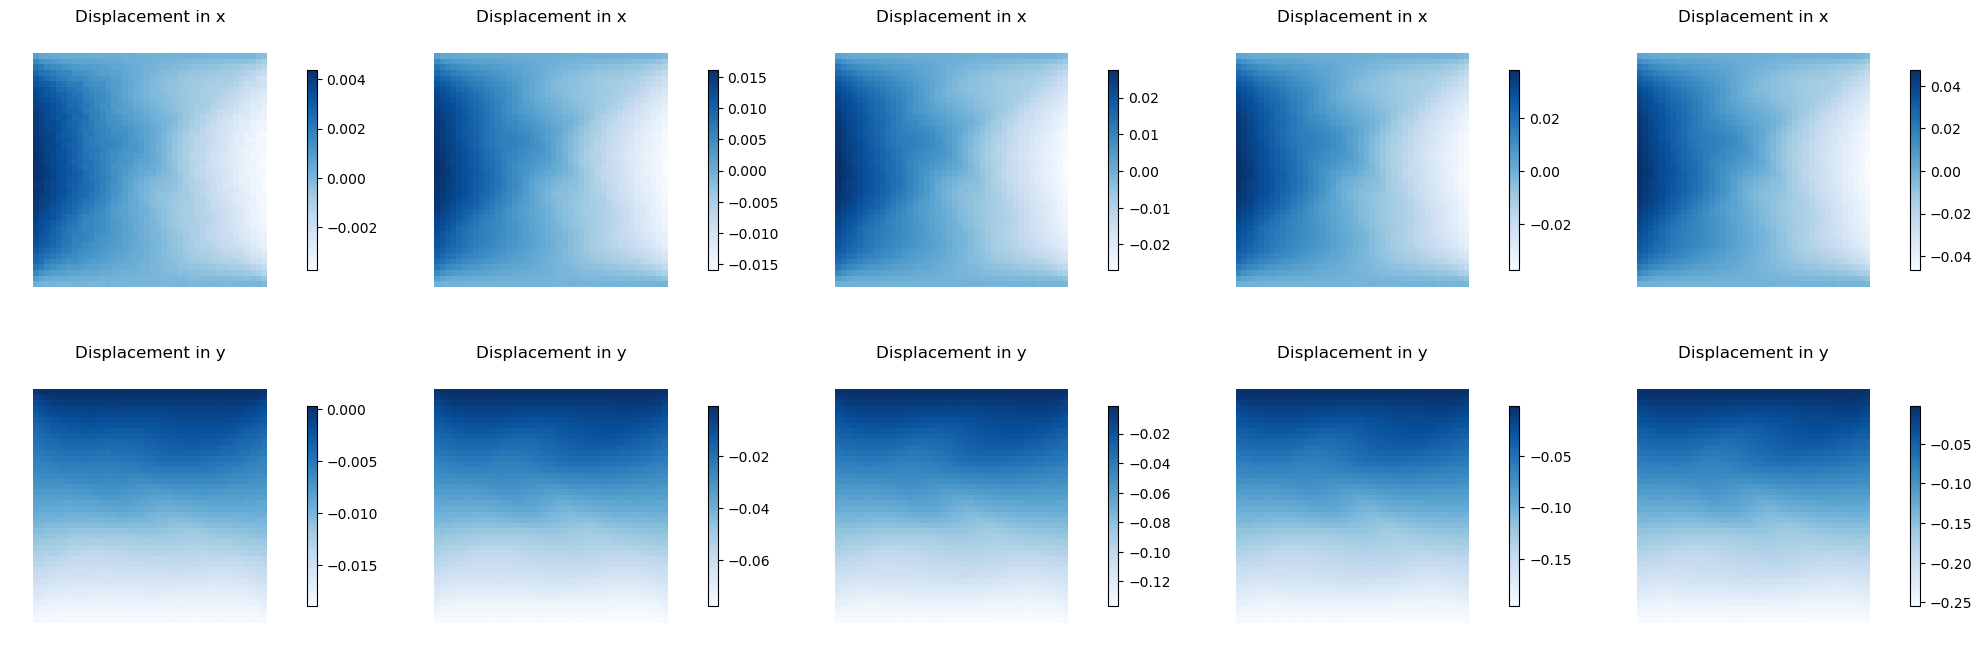

In [4]:
ele_type = 'QUAD4'
cell_type = get_meshio_cell_type(ele_type)

Nx, Ny = x2.shape[0], x2.shape[1]
Lx, Ly = 1.0, 1.0
meshio_mesh = rectangle_mesh(Nx=Nx, Ny=Ny, domain_x=Lx, domain_y=Ly)
mesh = Mesh(meshio_mesh.points, meshio_mesh.cells_dict[cell_type])

disps = []
n_panels = 5
fig, axes = plt.subplots(2,n_panels,figsize=(5*n_panels,8))
t_hist = np.arange(len(F_hist))
for i in range(len(F_hist)):
    t = t_hist[i]
    plotmesh(mesh.cells, mesh.points, ux_hist[i].flatten(), title='Displacement in x', ax=axes[0,i], ec='None'); 
    plotmesh(mesh.cells, mesh.points, uy_hist[i].flatten(), title='Displacement in y', ax=axes[1,i], ec='None'); 
    temp = np.array([t*np.ones(len(ux_hist[i].flatten())), ux_hist[i].flatten(), uy_hist[i].flatten()])
    disps.append(np.array([t*np.ones(len(ux_hist[i].flatten())), ux_hist[i].flatten(), uy_hist[i].flatten()]))
disps = np.hstack(disps)

### Coords_2_displacement NN

In [5]:
# normalize the displacements (excluding the lmb (time) column)
disps_mean = disps[1:].mean()
disps_stdv = disps[1:].std()
disps_norm = disps.copy()
disps_norm[1:] = (disps[1:]-disps_mean)/disps_stdv

def loss_coords_2_disp(params, X, key):
    inp, out_gt = X[:,:3], X[:,3:] # X consists of 5 columns: X, Y, lmb (time), ux, uy. The first 3 are inputs of the NN and the last 2 the outputs.
    t = inp[:,2:3]
    out_pr = coords_2_strain_nn(inp, params)
    out_gt = out_gt/(t+1) #dividing by t+1 just for some regularization
    out_pr = out_pr/(t+1) #dividing by t+1 just for some regularization
    return jnp.mean((out_pr-out_gt)**2)


n_ff = 100 # 10 cosines and 10 sines in the fourier features
n_inp = 2 # x, y
ff_params = np.random.normal(size=n_inp*n_ff).reshape([n_inp,n_ff])*0.5
nn_layers = [2*n_ff+1,100,50,40,2]


nn_params = init_params_nn(nn_layers, key)
coord_2_strain_params = [ff_params, nn_params]

# lr = optimizers.exponential_decay(8e-4, 10000, 0.9)
lr = optimizers.exponential_decay(4e-4, 4000, 0.9)
opt_init, opt_update, get_params = optimizers.adam(lr)
opt_state = opt_init(coord_2_strain_params)

X = np.vstack([elem_X2]*len(F_hist))
inp = np.hstack([X, disps_norm.T])
coord_2_strain_params, train_loss, _ = train(loss_coords_2_disp, inp, get_params, opt_update, opt_state, key, nIter = 50000, print_freq=1000)

it 1000, train loss = 1.166303e-04
it 2000, train loss = 4.644232e-05
it 3000, train loss = 2.321207e-05
it 4000, train loss = 1.306628e-05
it 5000, train loss = 8.398748e-06
it 6000, train loss = 6.078639e-06
it 7000, train loss = 4.863890e-06
it 8000, train loss = 4.078097e-06
it 9000, train loss = 3.556164e-06
it 10000, train loss = 1.462845e-05
it 11000, train loss = 6.512872e-05
it 12000, train loss = 2.715288e-06
it 13000, train loss = 1.619430e-05
it 14000, train loss = 2.606796e-06
it 15000, train loss = 2.334448e-06
it 16000, train loss = 2.311340e-06
it 17000, train loss = 2.196246e-06
it 18000, train loss = 1.235091e-05
it 19000, train loss = 2.017701e-06
it 20000, train loss = 1.910665e-06
it 21000, train loss = 1.842051e-06
it 22000, train loss = 1.765569e-05
it 23000, train loss = 1.757124e-06
it 24000, train loss = 1.720044e-06
it 25000, train loss = 2.774454e-06
it 26000, train loss = 1.661204e-06
it 27000, train loss = 1.612320e-06
it 28000, train loss = 1.693719e-06
i

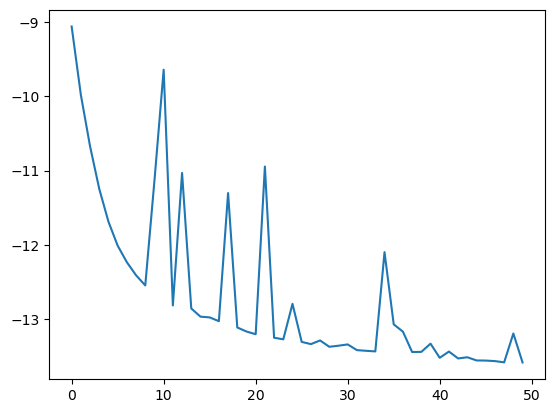

In [6]:
plt.plot(np.log(train_loss))

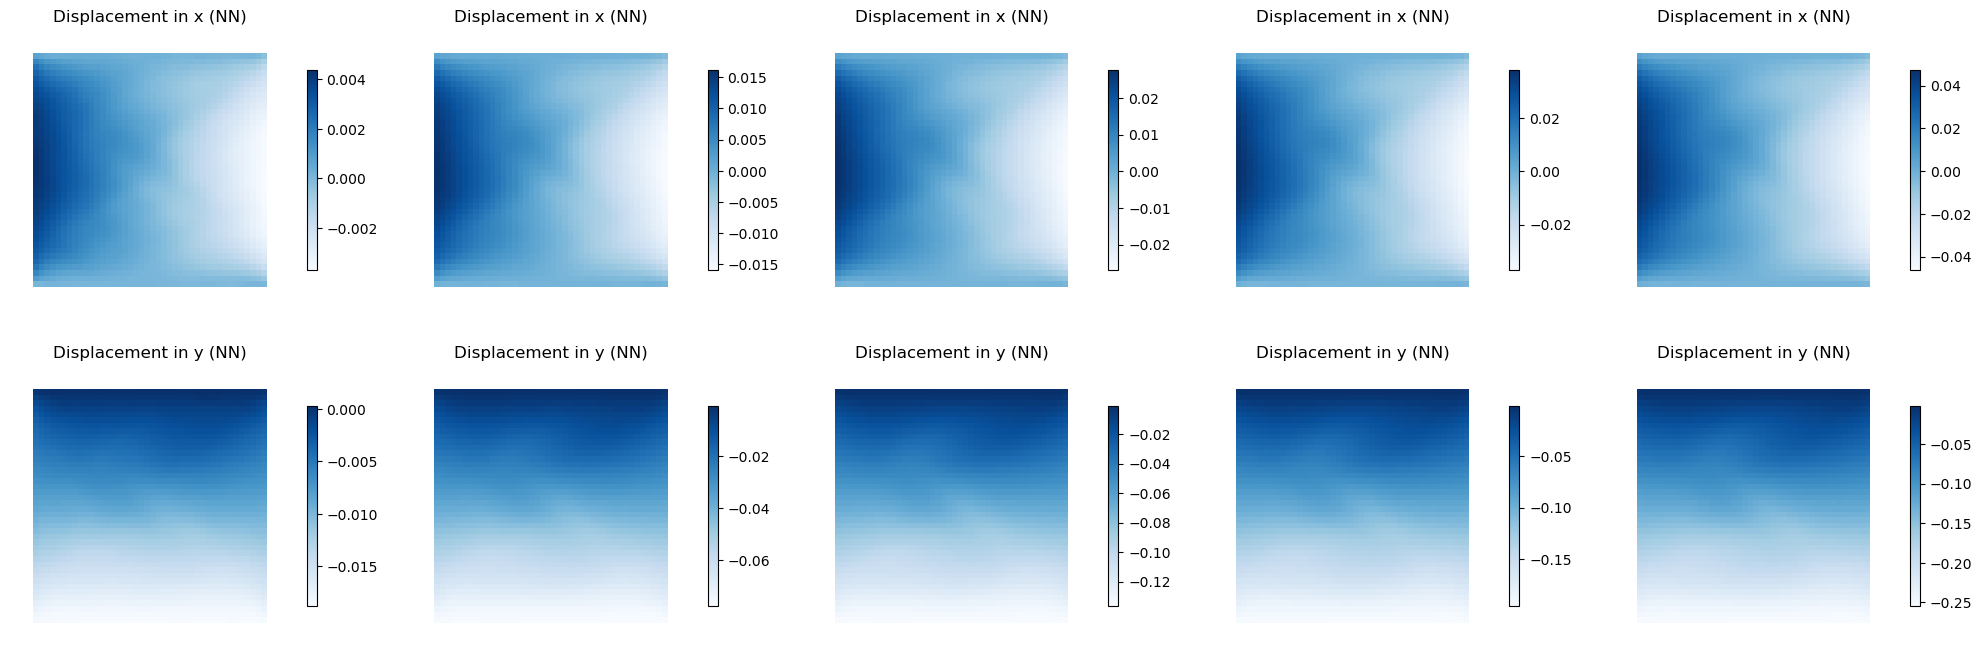

In [7]:
fig, axes = plt.subplots(2,5,figsize=(25,8))
for t in t_hist:
    aux = np.hstack([elem_X2, t*np.ones_like(elem_X2[:,:1])])
    disp_x, disp_y = coords_2_strain_nn(aux, coord_2_strain_params).T

    disp_x = disp_x*disps_stdv + disps_mean
    disp_y = disp_y*disps_stdv + disps_mean
    
    plotmesh(mesh.cells, mesh.points, disp_x, title='Displacement in x (NN)', ax=axes[0, t], ec='None'); 
    plotmesh(mesh.cells, mesh.points, disp_y, title='Displacement in y (NN)', ax=axes[1, t], ec='None'); 

### Coords_2_strain NN

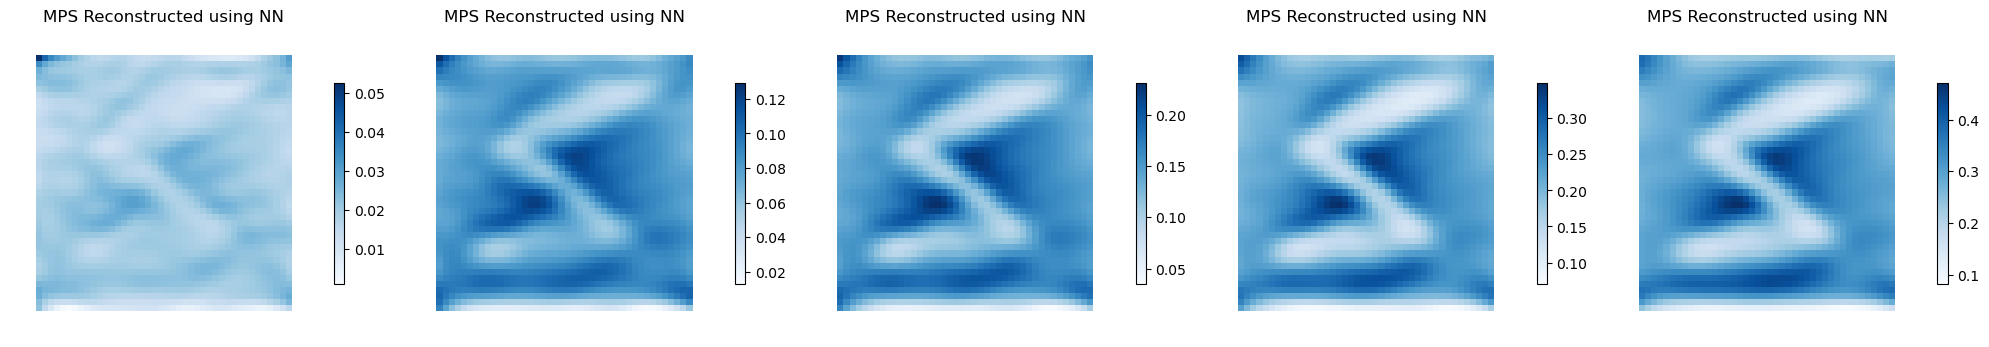

In [9]:
fig, axes = plt.subplots(1,5,figsize=(25,4))
for t in t_hist:
    aux = np.hstack([elem_X2, t*np.ones_like(elem_X2[:,:1])])
    F_xx, F_xy, F_yx, F_yy = coords_2_strain_nn2(aux, coord_2_strain_params).T
    F = np.stack([F_xx, F_xy, F_yx, F_yy]).T.reshape([-1,2,2])
    
    E = E_fun(F)
    evals, efuns = jnp.linalg.eigh(E)
    E_11, E_22 = evals.T
    mps = np.maximum(E_11, E_22)

    if t < 5:
        plotmesh(mesh.cells, mesh.points, mps, title='MPS Reconstructed using NN', ax=axes[t], ec='None'); 

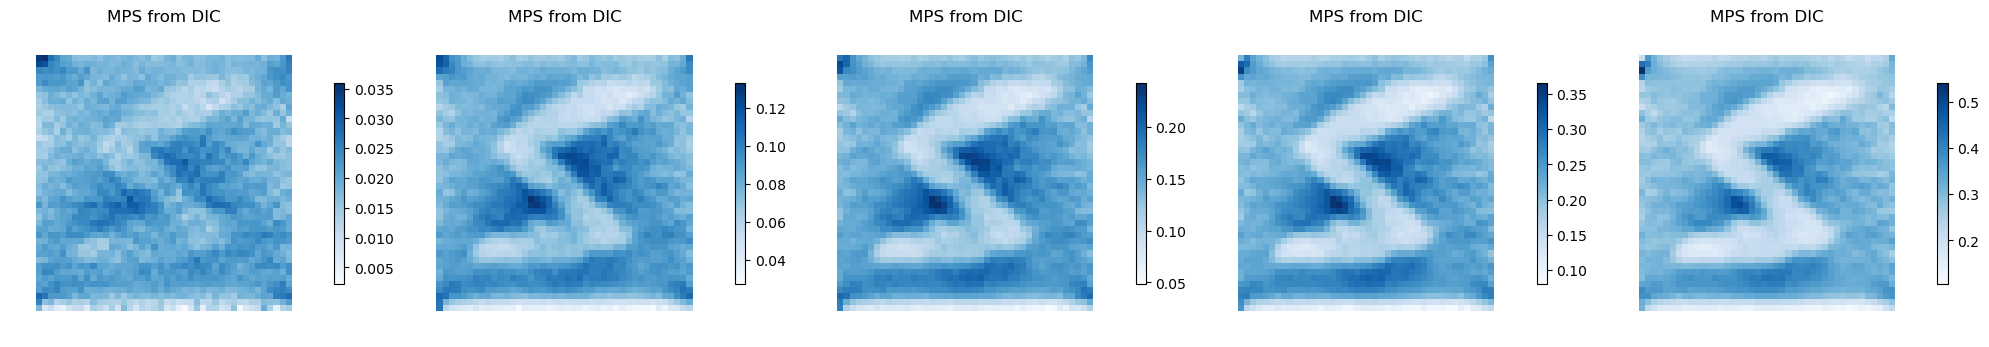

In [10]:
fig, axes = plt.subplots(1,5,figsize=(25,4))
for t in t_hist:
    E = E_hist_dic[t].transpose([2,0,1]).reshape([42,43,2,2]).transpose([1,0,2,3])[:42,:,:,:].reshape([-1,2,2]) # I know. wtf?
    evals, efuns = jnp.linalg.eigh(E)
    E_11, E_22 = evals.T
    mps = np.maximum(E_11, E_22)

    if t < 5:
        plotmesh(mesh.cells, mesh.points, mps, title='MPS from DIC', ax=axes[t], ec='None'); 

In [11]:
# identify the boundaries
rgt_bd_elems = []
top_bd_elems = []
lft_bd_elems = []
bot_bd_elems = []
for i, e in enumerate(mesh.cells):
    if any([mesh.points[e[i],0]>0.99 for i in range(4)]):
        rgt_bd_elems.append(i)
    if any([mesh.points[e[i],1]>0.99 for i in range(4)]):
        top_bd_elems.append(i)
    if any([mesh.points[e[i],0]<0.01 for i in range(4)]):
        lft_bd_elems.append(i)
    if any([mesh.points[e[i],1]<0.01 for i in range(4)]):
        bot_bd_elems.append(i)

# get the center points of the elements
rgt_bd_X = elem_X2[rgt_bd_elems]
top_bd_X = elem_X2[top_bd_elems]
lft_bd_X = elem_X2[lft_bd_elems]
bot_bd_X = elem_X2[bot_bd_elems]
bd_X = rgt_bd_X, top_bd_X, lft_bd_X, bot_bd_X

In [12]:
# Homogenize the strains
inputs = np.array([F_xx_mean, F_xy_mean, F_yx_mean, F_yy_mean, P_xx_gt, P_yy_gt]).T

n_neurons = 4
# Define the loss function for when training all params
@jit
def loss_stress(params, x, key):
    model = NODE_model_aniso(params)
    F_xx, F_xy, F_yx, F_yy, P_xx_gt, P_yy_gt = x.T
    P = eval_P_vmap(F_xx, F_xy, F_yx, F_yy, model)
    P_xx_pr, P_yy_pr = P[:,0,0], P[:,1,1]
    return np.mean((P_xx_pr-P_xx_gt)**2+(P_yy_pr-P_yy_gt)**2)

# Initialize NODEs and the optimizer
key = random.PRNGKey(0)
common_layers = [1, n_neurons, n_neurons]
sample_layers = [n_neurons,1]
node_params = init_params_aniso(common_layers, sample_layers, key)
opt_init, opt_update, get_params = optimizers.adam(1.e-3) #Original: 1.e-4
opt_state = opt_init(node_params)

# Train
node_params, train_loss, _ = train(loss_stress, inputs, get_params, opt_update, opt_state, key, nIter = 50000, print_freq=1000)

it 1000, train loss = 5.346436e-01
it 2000, train loss = 3.305470e-01
it 3000, train loss = 2.260410e-01
it 4000, train loss = 1.110928e-01
it 5000, train loss = 5.965621e-02
it 6000, train loss = 4.482782e-02
it 7000, train loss = 4.053991e-02
it 8000, train loss = 3.843228e-02
it 9000, train loss = 3.713387e-02
it 10000, train loss = 3.622376e-02
it 11000, train loss = 3.552673e-02
it 12000, train loss = 3.495787e-02
it 13000, train loss = 3.441387e-02
it 14000, train loss = 3.388686e-02
it 15000, train loss = 3.369429e-02
it 16000, train loss = 3.360483e-02
it 17000, train loss = 3.354492e-02
it 18000, train loss = 3.350472e-02
it 19000, train loss = 3.347730e-02
it 20000, train loss = 3.345807e-02
it 21000, train loss = 3.344848e-02
it 22000, train loss = 3.343436e-02
it 23000, train loss = 3.342711e-02
it 24000, train loss = 3.342178e-02
it 25000, train loss = 3.341865e-02
it 26000, train loss = 3.341486e-02
it 27000, train loss = 3.341247e-02
it 28000, train loss = 3.341056e-02
i

gt P_xx & P_yy:  [0. 0. 0. 0. 0.] [0.42178 1.16735 1.77345 2.31518 2.81071]
pr P_xx & P_yy:  [0.05122 0.14781 0.18835 0.19688 0.18691] [0.30149 1.06658 1.7058  2.29446 2.8717 ]
The discrepancy happens because the strains are weird. For example, incompressibility is not satisfied, apparently.


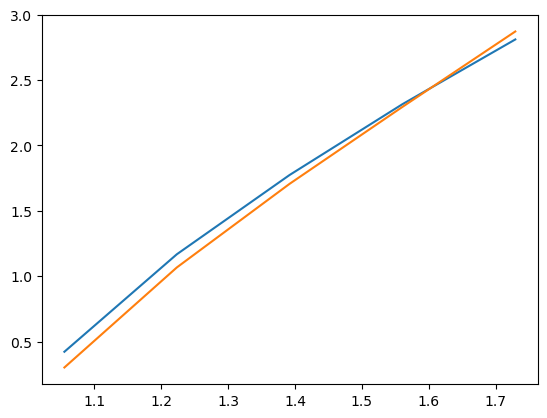

In [13]:
mymodel = NODE_model_aniso(node_params)
P = eval_P_vmap(F_xx_mean, F_xy_mean, F_yx_mean, F_yy_mean, mymodel)
P_xx_pr, P_yy_pr = P[:,0,0], P[:,1,1]
print('gt P_xx & P_yy: ', P_xx_gt, P_yy_gt)
print('pr P_xx & P_yy: ', P_xx_pr, P_yy_pr)
print('The discrepancy happens because the strains are weird. For example, incompressibility is not satisfied, apparently.')

fig, ax = plt.subplots()
ax.plot(F_yy_mean, P_yy_gt)
ax.plot(F_yy_mean, P_yy_pr)

In [14]:
# Fit a function Λ that maps x,y ∈ [0,1] to the individual-specific parameters of this NODE with a maximum variance of, say, 1%
common_params, sample_params = split_c_s_params(node_params)
phi, unravel = ravel_pytree(sample_params)
n_phi = len(phi)

# ff_params = coord_2_strain_params[0]
# ff_nn2 = lambda x, nn_params: ff_nn(x, [ff_params, nn_params])
def loss_Lambda(params, inp, key):
    out_pr = ff_nn(inp, params)
    return jnp.mean((out_pr-phi)**2)

n_ff = 100
ff_params = np.random.normal(size=2*n_ff).reshape([2,n_ff])
nn_layers = [2*n_ff,100,50,50,n_phi]
nn_params = init_params_nn(nn_layers, key)
Lambda_params = [ff_params, nn_params]
opt_init, opt_update, get_params = optimizers.adam(5.e-4) #Original: 1.e-4
opt_state = opt_init(Lambda_params)

inp = np.array(np.meshgrid(np.linspace(0,1,20), np.linspace(0,1,20))).reshape([2,-1]).T
Lambda_params, train_loss, _ = train(loss_Lambda, inp, get_params, opt_update, opt_state, key, nIter = 5000, print_freq=1000)

it 1000, train loss = 1.711921e-02
it 2000, train loss = 6.389586e-08
it 3000, train loss = 5.467553e-08
it 4000, train loss = 5.447858e-08
it 5000, train loss = 5.415495e-08


In [15]:
with open('params/AM_stiff2_pre.npy', 'wb') as f:
    pickle.dump([coord_2_strain_params, node_params, Lambda_params, mesh, elem_X, P_xx_gt, P_yy_gt, strains,
                 bd_X, F_hist, t_hist, disps_mean, disps_stdv, Nx, Ny], f)

## 2. Retrain

In [4]:
with open('params/AM_stiff2_pre.npy', 'rb') as f:
    coord_2_strain_params, node_params, Lambda_params, mesh, elem_X, P_xx_gt, P_yy_gt, strains, \
                 bd_X, F_hist, t_hist, disps_mean, disps_stdv, Nx, Ny = pickle.load(f)

common_params, sample_params = split_c_s_params(node_params)
_, unravel = ravel_pytree(sample_params)
NODE_w_unravel = lambda params: NODE_model_aniso(merge_c_s_params(common_params, unravel(params)))

In [ ]:
# Train
a1 = 1.0
a2 = 1.0
@jit
def loss(Lambda_params, XYt_colloc):
    Div_x, Div_y = divergence(Lambda_params, XYt_colloc, coord_2_strain_params, NODE_w_unravel)
    loss_Div = a1*(Div_x**2 + Div_y**2)

    def bd_forces_loss(_, t):
        F_rgt, F_top, F_lft, F_bot = bd_forces(Lambda_params, t, bd_X, coord_2_strain_params, NODE_w_unravel)
        P_rgt, P_top, P_lft, P_bot = F_rgt/Ny, F_top/Nx, F_lft/Ny, F_bot/Nx
        Px = P_xx_gt[jnp.array(t, int)]
        Py = P_yy_gt[jnp.array(t, int)]
        return None, a2*((P_rgt-Px)**2 + (P_top-Py)**2 + (P_lft-Px)**2 + (P_bot-Py)**2)
    loss_F = jnp.mean(scan(bd_forces_loss, init=None, xs=t_hist)[1])
    # loss_F = 0.0
    
    return loss_Div + loss_F

# lr = 1e-4
lr = optimizers.exponential_decay(1e-5, 5000, 0.9)
sharding = PositionalSharding(jax.devices()).reshape(n_cores, 1)
opt_init, opt_update, get_params = optimizers.adam(lr) 
opt_state = opt_init(Lambda_params)

node_X_ext = jnp.hstack([mesh.points, t_hist[-1]*np.ones_like(mesh.points[:,:1])])
metric1 = lambda params, X:  bd_forces(params, t_hist[-1], bd_X, coord_2_strain_params, NODE_w_unravel)
metric2 = lambda params, X: divergence(params, node_X_ext, coord_2_strain_params, NODE_w_unravel)

Lambda_params, val_loss, metrics = train_colloc(loss, [mesh.points, t_hist], get_params, opt_update, opt_state, 
                                            key, sharding, 'cross', nIter = 10000, print_freq=1000, batch_size=1000)

with open('params/AM_stiff2_post.npy', 'wb') as f:
    pickle.dump([mesh, elem_X, strains, P_xx_gt, P_yy_gt, node_params, Lambda_params, val_loss, metrics, t_hist], f)

## 3. Test

In [ ]:
with open('params/AM_stiff2_post.npy', 'rb') as f:
    mesh, elem_X, strains, Force_x, Force_y, node_params, Lambda_params, val_loss, metrics, t_hist = pickle.load(f)
common_params, sample_params = split_c_s_params(node_params)
_, unravel = ravel_pytree(sample_params)
NODE_w_unravel = lambda params: NODE_model_aniso(merge_c_s_params(common_params, unravel(params)))

In [4]:
cell_type = get_meshio_cell_type('QUAD4')
Nx, Ny = 50, 50
Lx, Ly = 1.0, 1.0
meshio_mesh = rectangle_mesh(Nx=Nx, Ny=Ny, domain_x=Lx, domain_y=Ly)
mesh2 = Mesh(meshio_mesh.points, meshio_mesh.cells_dict[cell_type])
elem_X2 = mesh2.points[mesh2.cells].mean(axis=1)

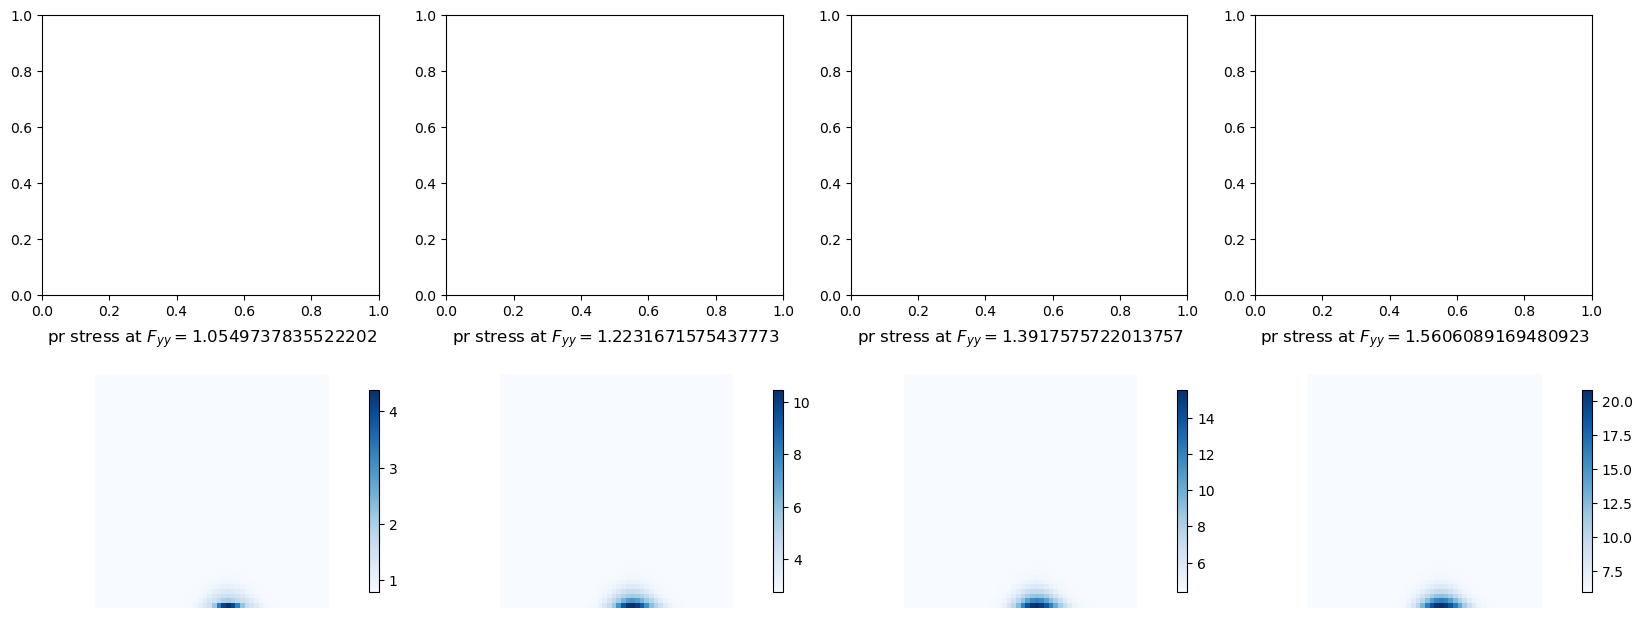

In [ ]:
# Stiffness across the domain
fig, axes = plt.subplots(2,4,figsize=(20,8))
lmb_hist = [1.01929, 1.02728, 1.03531, 1.0433 , 1.05132]

extents = [[0.018, 0.021],
           [0.07, 0.08],
           [0.115, 0.13],
           [0.155, 0.17]]
for F_xx, F_yy, F_xy, F_yx, ax, extent in zip(F_xx_mean, F_yy_mean, F_xy_mean, F_yx_mean, axes.T, extents):
    # # ugrad = jnp.array([[lmb-1.0, 0.0], [0.0, lmb-1.0]])
    # lmbx = 1.0/lmb
    # ugrad = jnp.array([[lmbx-1.0, 0.0], [0.0, lmb-1.0]])

    F = np.array([[F_xx, F_xy],
                  [F_yx, F_yy]])
    ugrad = F - np.eye(2)

    # params_gt = []
    # for xy in elem_X:
    #     params_gt.append(coords_2_params_gt(xy))
    # params_gt = np.array(params_gt)
    params_pr = ff_nn(elem_X2, Lambda_params)

    # c_elem_gt = []
    c_elem_pr = []
    # for params_gt_i, params_pr_i in zip(params_gt, params_pr):
    for params_pr_i in params_pr:
        # c_elem_gt.append(ThreeDElasticity(GOH_model).ugrad_2_P(ugrad, params_gt_i, 2)[0,0])
        c_elem_pr.append(ThreeDElasticity(NODE_w_unravel).ugrad_2_P(ugrad, params_pr_i, 2)[1,1])

    # plotmesh(mesh.cells, mesh.points, c_elem_gt, title='gt stress at {}'.format(str(lmb)), ax=ax[0]); 
    # extent = [np.min(c_elem_gt), np.max(c_elem_gt)]

    # if extent[0] > np.min(c_elem_pr) and extent[1] < np.max(c_elem_pr):
    #     extend='both'
    # elif extent[0] > np.min(c_elem_pr):
    #     extend='min'
    # elif extent[1] < np.max(c_elem_pr):
    #     extend='max'
    plotmesh(mesh2.cells, mesh2.points, c_elem_pr, title='pr stress at $F_{yy}=$' + str(F_yy), ax=ax[1], ec='None'); 

it 1, val loss = 4.213452e+00
it 1001, val loss = 3.290408e+00
it 2001, val loss = 3.331649e+00
it 3001, val loss = 3.138407e+00
it 4001, val loss = 2.873596e+00
it 5001, val loss = 2.581231e+00
it 6001, val loss = 2.293969e+00
it 7001, val loss = 1.944258e+00
it 8001, val loss = 1.819591e+00
it 9001, val loss = 1.681537e+00


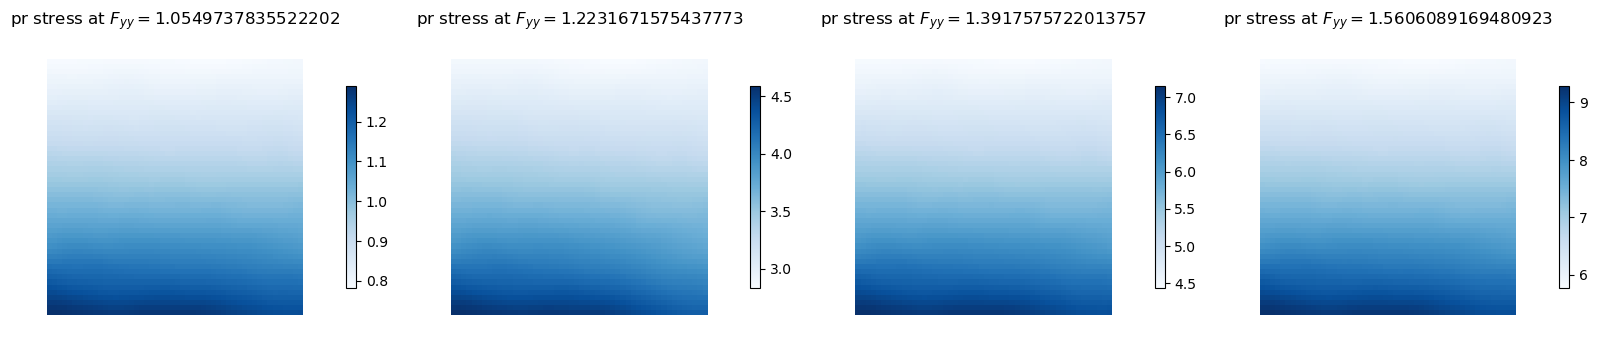

In [2]:
with open('params/AM_stiff2_pre.npy', 'rb') as f:
    coord_2_strain_params, node_params, Lambda_params, mesh, elem_X, P_xx_gt, P_yy_gt, strains, \
                 bd_X, F_hist, t_hist, disps_mean, disps_stdv, Nx, Ny = pickle.load(f)

common_params, sample_params = split_c_s_params(node_params)
phi, unravel = ravel_pytree(sample_params)
NODE_w_unravel = lambda params: NODE_model_aniso(merge_c_s_params(common_params, unravel(params)))


a1 = 1.0
a2 = 1.0
a3 = 1.0*2**(0)
@jit
def loss(Lambda_params, XYt_colloc):
    Div_x, Div_y = divergence(Lambda_params, XYt_colloc, coord_2_strain_params, NODE_w_unravel)
    loss_Div = (Div_x**2 + Div_y**2)

    def bd_forces_loss(_, t):
        F_rgt, F_top, F_lft, F_bot = bd_forces(Lambda_params, t, bd_X, coord_2_strain_params, NODE_w_unravel)
        P_rgt, P_top, P_lft, P_bot = F_rgt/Ny, F_top/Nx, F_lft/Ny, F_bot/Nx
        Px = P_xx_gt[jnp.array(t, int)]
        Py = P_yy_gt[jnp.array(t, int)]
        return None, ((P_rgt-Px)**2 + (P_top-Py)**2 + (P_lft-Px)**2 + (P_bot-Py)**2)
    loss_F = jnp.mean(scan(bd_forces_loss, init=None, xs=t_hist)[1])
    
    # Add TVR loss
    tvr_loss = 0.0
    Lambda_inp = jnp.array([XYt_colloc[:,0],XYt_colloc[:,1]]).reshape([-1,2])
    for i in range(len(phi)):
        grads = vmap(grad(lambda inp: ff_nn(inp, Lambda_params)[i]))(Lambda_inp) # Take derivative of the ith output wrt the input vector
        tvr_loss += jnp.mean(jnp.sum(grads*grads, axis=1))
     
    return a1*loss_Div + a2*loss_F + a3*tvr_loss

lr = optimizers.exponential_decay(1e-5, 5000, 0.9)
sharding = PositionalSharding(jax.devices()).reshape(n_cores, 1)
opt_init, opt_update, get_params = optimizers.adam(lr) 
opt_state = opt_init(Lambda_params)

Lambda_params, val_loss, metrics = train_colloc(loss, [mesh.points, t_hist], get_params, opt_update, opt_state, 
                                            key, sharding, 'cross', nIter = 10000, print_freq=1000, batch_size=1000)

with open('params/AM_stiff2_TVR00_post.npy', 'wb') as f:
    pickle.dump([mesh, elem_X, strains, P_xx_gt, P_yy_gt, node_params, Lambda_params, val_loss, metrics, t_hist], f)

# Stiffness across the domain
fig, axes = plt.subplots(1,4,figsize=(20,4))

cell_type = get_meshio_cell_type('QUAD4')
Nx, Ny = 50, 50
Lx, Ly = 1.0, 1.0
meshio_mesh = rectangle_mesh(Nx=Nx, Ny=Ny, domain_x=Lx, domain_y=Ly)
mesh2 = Mesh(meshio_mesh.points, meshio_mesh.cells_dict[cell_type])
elem_X2 = mesh2.points[mesh2.cells].mean(axis=1)
for F_xx, F_yy, F_xy, F_yx, ax in zip(F_xx_mean, F_yy_mean, F_xy_mean, F_yx_mean, axes.T):
    F = np.array([[F_xx, F_xy],
                  [F_yx, F_yy]])
    ugrad = F - np.eye(2)

    params_pr = ff_nn(elem_X2, Lambda_params)

    c_elem_pr = []
    for params_pr_i in params_pr:
        c_elem_pr.append(ThreeDElasticity(NODE_w_unravel).ugrad_2_P(ugrad, params_pr_i, 2)[1,1])
    plotmesh(mesh2.cells, mesh2.points, c_elem_pr, title='pr stress at $F_{yy}=$' + str(F_yy), ax=ax, ec='None'); 

it 1, val loss = 4.211769e+00
it 1001, val loss = 2.570655e+00
it 2001, val loss = 1.288109e+00
it 3001, val loss = 1.161625e+00
it 4001, val loss = 9.345279e-01
it 5001, val loss = 8.857427e-01
it 6001, val loss = 9.583757e-01
it 7001, val loss = 9.630519e-01
it 8001, val loss = 9.027986e-01
it 9001, val loss = 8.383541e-01


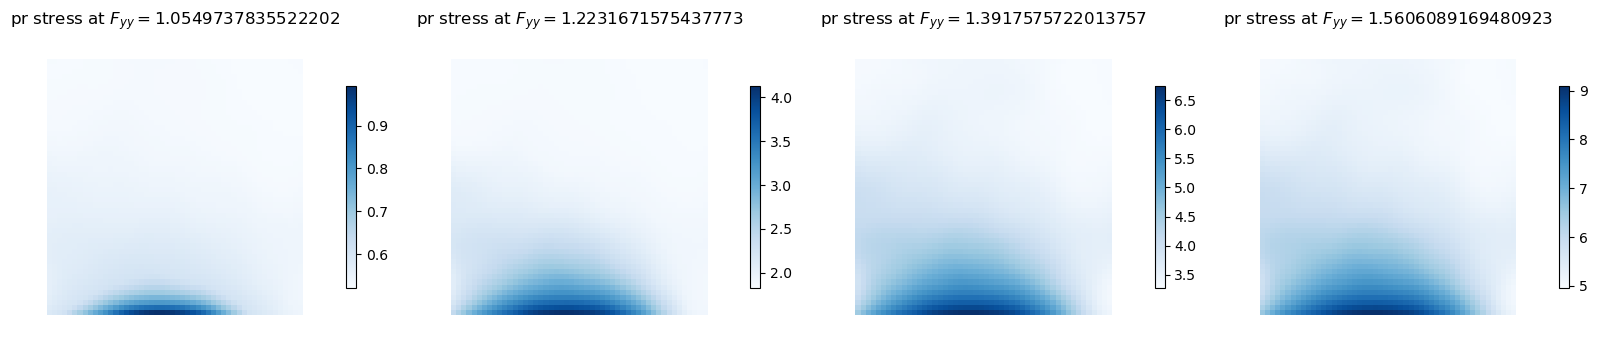

In [2]:
with open('params/AM_stiff2_pre.npy', 'rb') as f:
    coord_2_strain_params, node_params, Lambda_params, mesh, elem_X, P_xx_gt, P_yy_gt, strains, \
                 bd_X, F_hist, t_hist, disps_mean, disps_stdv, Nx, Ny = pickle.load(f)

common_params, sample_params = split_c_s_params(node_params)
phi, unravel = ravel_pytree(sample_params)
NODE_w_unravel = lambda params: NODE_model_aniso(merge_c_s_params(common_params, unravel(params)))


a1 = 1.0
a2 = 1.0
a3 = 0.1
@jit
def loss(Lambda_params, XYt_colloc):
    Div_x, Div_y = divergence(Lambda_params, XYt_colloc, coord_2_strain_params, NODE_w_unravel)
    loss_Div = (Div_x**2 + Div_y**2)

    def bd_forces_loss(_, t):
        F_rgt, F_top, F_lft, F_bot = bd_forces(Lambda_params, t, bd_X, coord_2_strain_params, NODE_w_unravel)
        P_rgt, P_top, P_lft, P_bot = F_rgt/Ny, F_top/Nx, F_lft/Ny, F_bot/Nx
        Px = P_xx_gt[jnp.array(t, int)]
        Py = P_yy_gt[jnp.array(t, int)]
        return None, ((P_rgt-Px)**2 + (P_top-Py)**2 + (P_lft-Px)**2 + (P_bot-Py)**2)
    loss_F = jnp.mean(scan(bd_forces_loss, init=None, xs=t_hist)[1])
    
    # Add TVR loss
    tvr_loss = 0.0
    Lambda_inp = jnp.array([XYt_colloc[:,0],XYt_colloc[:,1]]).reshape([-1,2])
    for i in range(len(phi)):
        grads = vmap(grad(lambda inp: ff_nn(inp, Lambda_params)[i]))(Lambda_inp) # Take derivative of the ith output wrt the input vector
        tvr_loss += jnp.mean(jnp.sum(grads*grads, axis=1))
     
    return a1*loss_Div + a2*loss_F + a3*tvr_loss

lr = optimizers.exponential_decay(1e-5, 5000, 0.9)
sharding = PositionalSharding(jax.devices()).reshape(n_cores, 1)
opt_init, opt_update, get_params = optimizers.adam(lr) 
opt_state = opt_init(Lambda_params)

Lambda_params, val_loss, metrics = train_colloc(loss, [mesh.points, t_hist], get_params, opt_update, opt_state, 
                                            key, sharding, 'cross', nIter = 10000, print_freq=1000, batch_size=1000)

with open('params/AM_stiff2_TVR00_post.npy', 'wb') as f:
    pickle.dump([mesh, elem_X, strains, P_xx_gt, P_yy_gt, node_params, Lambda_params, val_loss, metrics, t_hist], f)

# Stiffness across the domain
fig, axes = plt.subplots(1,4,figsize=(20,4))
cell_type = get_meshio_cell_type('QUAD4')
Nx, Ny = 50, 50
Lx, Ly = 1.0, 1.0
meshio_mesh = rectangle_mesh(Nx=Nx, Ny=Ny, domain_x=Lx, domain_y=Ly)
mesh2 = Mesh(meshio_mesh.points, meshio_mesh.cells_dict[cell_type])
elem_X2 = mesh2.points[mesh2.cells].mean(axis=1)
for F_xx, F_yy, F_xy, F_yx, ax in zip(F_xx_mean, F_yy_mean, F_xy_mean, F_yx_mean, axes.T):
    F = np.array([[F_xx, F_xy],
                  [F_yx, F_yy]])
    ugrad = F - np.eye(2)

    params_pr = ff_nn(elem_X2, Lambda_params)

    c_elem_pr = []
    for params_pr_i in params_pr:
        c_elem_pr.append(ThreeDElasticity(NODE_w_unravel).ugrad_2_P(ugrad, params_pr_i, 2)[1,1])
    plotmesh(mesh2.cells, mesh2.points, c_elem_pr, title='pr stress at $F_{yy}=$' + str(F_yy), ax=ax, ec='None'); 

it 1, val loss = 4.211675e+00
it 1001, val loss = 1.585604e+00
it 2001, val loss = 1.183220e+00
it 3001, val loss = 8.447932e-01
it 4001, val loss = 8.022146e-01
it 5001, val loss = 7.998005e-01
it 6001, val loss = 7.831703e-01
it 7001, val loss = 8.134702e-01
it 8001, val loss = 8.392762e-01
it 9001, val loss = 7.181104e-01


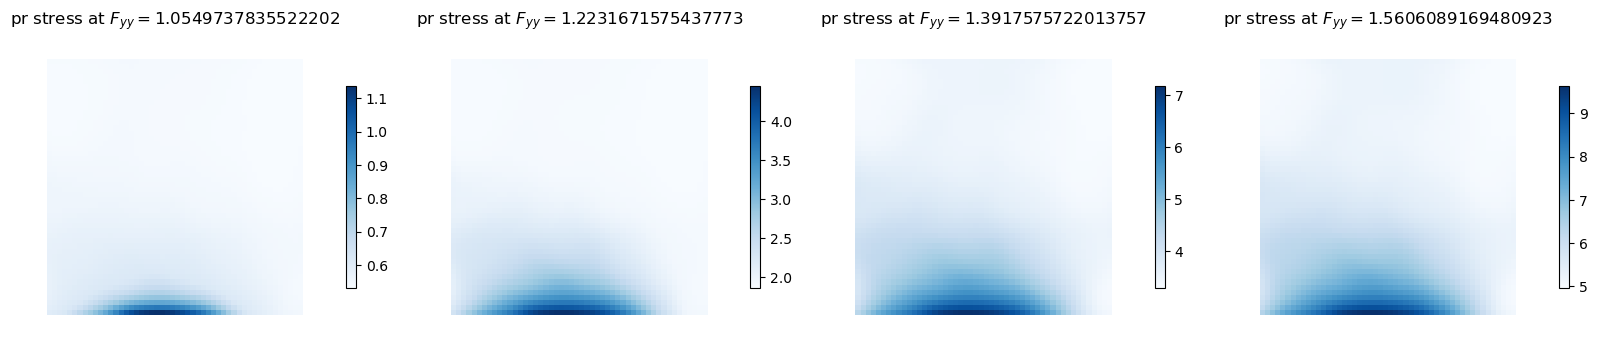

In [3]:
with open('params/AM_stiff2_pre.npy', 'rb') as f:
    coord_2_strain_params, node_params, Lambda_params, mesh, elem_X, P_xx_gt, P_yy_gt, strains, \
                 bd_X, F_hist, t_hist, disps_mean, disps_stdv, Nx, Ny = pickle.load(f)

common_params, sample_params = split_c_s_params(node_params)
phi, unravel = ravel_pytree(sample_params)
NODE_w_unravel = lambda params: NODE_model_aniso(merge_c_s_params(common_params, unravel(params)))


a1 = 1.0
a2 = 1.0
a3 = 0.1*2**(-1)
@jit
def loss(Lambda_params, XYt_colloc):
    Div_x, Div_y = divergence(Lambda_params, XYt_colloc, coord_2_strain_params, NODE_w_unravel)
    loss_Div = (Div_x**2 + Div_y**2)

    def bd_forces_loss(_, t):
        F_rgt, F_top, F_lft, F_bot = bd_forces(Lambda_params, t, bd_X, coord_2_strain_params, NODE_w_unravel)
        P_rgt, P_top, P_lft, P_bot = F_rgt/Ny, F_top/Nx, F_lft/Ny, F_bot/Nx
        Px = P_xx_gt[jnp.array(t, int)]
        Py = P_yy_gt[jnp.array(t, int)]
        return None, ((P_rgt-Px)**2 + (P_top-Py)**2 + (P_lft-Px)**2 + (P_bot-Py)**2)
    loss_F = jnp.mean(scan(bd_forces_loss, init=None, xs=t_hist)[1])
    
    # Add TVR loss
    tvr_loss = 0.0
    Lambda_inp = jnp.array([XYt_colloc[:,0],XYt_colloc[:,1]]).reshape([-1,2])
    for i in range(len(phi)):
        grads = vmap(grad(lambda inp: ff_nn(inp, Lambda_params)[i]))(Lambda_inp) # Take derivative of the ith output wrt the input vector
        tvr_loss += jnp.mean(jnp.sum(grads*grads, axis=1))
     
    return a1*loss_Div + a2*loss_F + a3*tvr_loss

lr = optimizers.exponential_decay(1e-5, 5000, 0.9)
sharding = PositionalSharding(jax.devices()).reshape(n_cores, 1)
opt_init, opt_update, get_params = optimizers.adam(lr) 
opt_state = opt_init(Lambda_params)

Lambda_params, val_loss, metrics = train_colloc(loss, [mesh.points, t_hist], get_params, opt_update, opt_state, 
                                            key, sharding, 'cross', nIter = 10000, print_freq=1000, batch_size=1000)

with open('params/AM_stiff2_TVR-1_post.npy', 'wb') as f:
    pickle.dump([mesh, elem_X, strains, P_xx_gt, P_yy_gt, node_params, Lambda_params, val_loss, metrics, t_hist], f)

# Stiffness across the domain
fig, axes = plt.subplots(1,4,figsize=(20,4))
cell_type = get_meshio_cell_type('QUAD4')
Nx, Ny = 50, 50
Lx, Ly = 1.0, 1.0
meshio_mesh = rectangle_mesh(Nx=Nx, Ny=Ny, domain_x=Lx, domain_y=Ly)
mesh2 = Mesh(meshio_mesh.points, meshio_mesh.cells_dict[cell_type])
elem_X2 = mesh2.points[mesh2.cells].mean(axis=1)
for F_xx, F_yy, F_xy, F_yx, ax in zip(F_xx_mean, F_yy_mean, F_xy_mean, F_yx_mean, axes.T):
    F = np.array([[F_xx, F_xy],
                  [F_yx, F_yy]])
    ugrad = F - np.eye(2)

    params_pr = ff_nn(elem_X2, Lambda_params)

    c_elem_pr = []
    for params_pr_i in params_pr:
        c_elem_pr.append(ThreeDElasticity(NODE_w_unravel).ugrad_2_P(ugrad, params_pr_i, 2)[1,1])
    plotmesh(mesh2.cells, mesh2.points, c_elem_pr, title='pr stress at $F_{yy}=$' + str(F_yy), ax=ax, ec='None'); 

it 1, val loss = 4.211627e+00
it 1001, val loss = 1.124820e+00
it 2001, val loss = 9.152809e-01
it 3001, val loss = 7.976706e-01
it 4001, val loss = 7.878178e-01
it 5001, val loss = 7.349100e-01
it 6001, val loss = 6.736215e-01
it 7001, val loss = 6.857543e-01
it 8001, val loss = 7.188838e-01
it 9001, val loss = 6.768958e-01


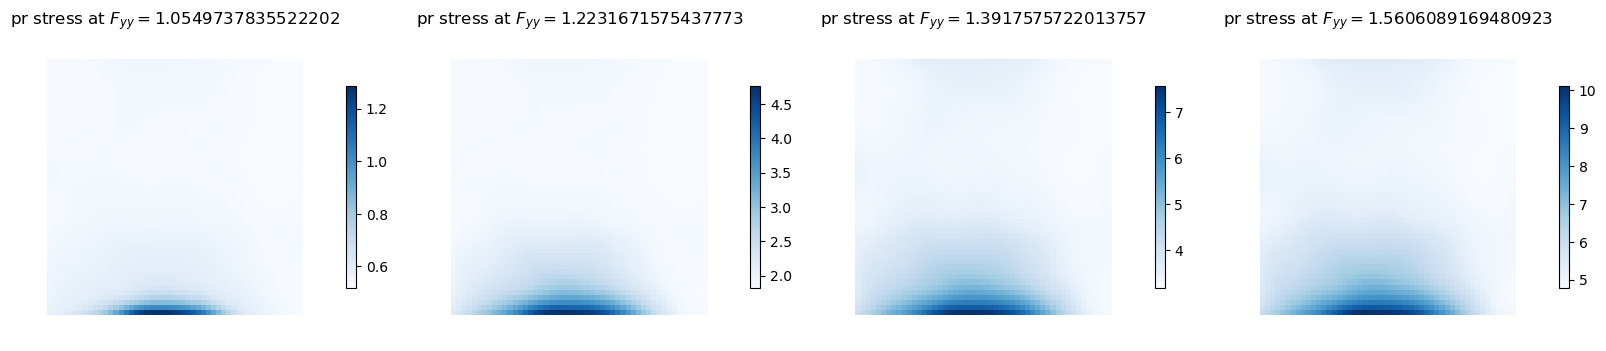

In [4]:
with open('params/AM_stiff2_pre.npy', 'rb') as f:
    coord_2_strain_params, node_params, Lambda_params, mesh, elem_X, P_xx_gt, P_yy_gt, strains, \
                 bd_X, F_hist, t_hist, disps_mean, disps_stdv, Nx, Ny = pickle.load(f)

common_params, sample_params = split_c_s_params(node_params)
phi, unravel = ravel_pytree(sample_params)
NODE_w_unravel = lambda params: NODE_model_aniso(merge_c_s_params(common_params, unravel(params)))


a1 = 1.0
a2 = 1.0
a3 = 0.1*2**(-2)
@jit
def loss(Lambda_params, XYt_colloc):
    Div_x, Div_y = divergence(Lambda_params, XYt_colloc, coord_2_strain_params, NODE_w_unravel)
    loss_Div = (Div_x**2 + Div_y**2)

    def bd_forces_loss(_, t):
        F_rgt, F_top, F_lft, F_bot = bd_forces(Lambda_params, t, bd_X, coord_2_strain_params, NODE_w_unravel)
        P_rgt, P_top, P_lft, P_bot = F_rgt/Ny, F_top/Nx, F_lft/Ny, F_bot/Nx
        Px = P_xx_gt[jnp.array(t, int)]
        Py = P_yy_gt[jnp.array(t, int)]
        return None, ((P_rgt-Px)**2 + (P_top-Py)**2 + (P_lft-Px)**2 + (P_bot-Py)**2)
    loss_F = jnp.mean(scan(bd_forces_loss, init=None, xs=t_hist)[1])
    
    # Add TVR loss
    tvr_loss = 0.0
    Lambda_inp = jnp.array([XYt_colloc[:,0],XYt_colloc[:,1]]).reshape([-1,2])
    for i in range(len(phi)):
        grads = vmap(grad(lambda inp: ff_nn(inp, Lambda_params)[i]))(Lambda_inp) # Take derivative of the ith output wrt the input vector
        tvr_loss += jnp.mean(jnp.sum(grads*grads, axis=1))
     
    return a1*loss_Div + a2*loss_F + a3*tvr_loss

lr = optimizers.exponential_decay(1e-5, 5000, 0.9)
sharding = PositionalSharding(jax.devices()).reshape(n_cores, 1)
opt_init, opt_update, get_params = optimizers.adam(lr) 
opt_state = opt_init(Lambda_params)

Lambda_params, val_loss, metrics = train_colloc(loss, [mesh.points, t_hist], get_params, opt_update, opt_state, 
                                            key, sharding, 'cross', nIter = 10000, print_freq=1000, batch_size=1000)

with open('params/AM_stiff2_TVR-2_post.npy', 'wb') as f:
    pickle.dump([mesh, elem_X, strains, P_xx_gt, P_yy_gt, node_params, Lambda_params, val_loss, metrics, t_hist], f)

# Stiffness across the domain
fig, axes = plt.subplots(1,4,figsize=(20,4))
cell_type = get_meshio_cell_type('QUAD4')
Nx, Ny = 50, 50
Lx, Ly = 1.0, 1.0
meshio_mesh = rectangle_mesh(Nx=Nx, Ny=Ny, domain_x=Lx, domain_y=Ly)
mesh2 = Mesh(meshio_mesh.points, meshio_mesh.cells_dict[cell_type])
elem_X2 = mesh2.points[mesh2.cells].mean(axis=1)
for F_xx, F_yy, F_xy, F_yx, ax in zip(F_xx_mean, F_yy_mean, F_xy_mean, F_yx_mean, axes.T):
    F = np.array([[F_xx, F_xy],
                  [F_yx, F_yy]])
    ugrad = F - np.eye(2)

    params_pr = ff_nn(elem_X2, Lambda_params)

    c_elem_pr = []
    for params_pr_i in params_pr:
        c_elem_pr.append(ThreeDElasticity(NODE_w_unravel).ugrad_2_P(ugrad, params_pr_i, 2)[1,1])
    plotmesh(mesh2.cells, mesh2.points, c_elem_pr, title='pr stress at $F_{yy}=$' + str(F_yy), ax=ax, ec='None'); 

it 1, val loss = 4.211604e+00
it 1001, val loss = 9.250120e-01
it 2001, val loss = 7.128598e-01
it 3001, val loss = 6.067061e-01
it 4001, val loss = 6.575525e-01
it 5001, val loss = 6.060731e-01
it 6001, val loss = 5.650127e-01
it 7001, val loss = 6.067813e-01
it 8001, val loss = 6.042293e-01
it 9001, val loss = 5.627529e-01


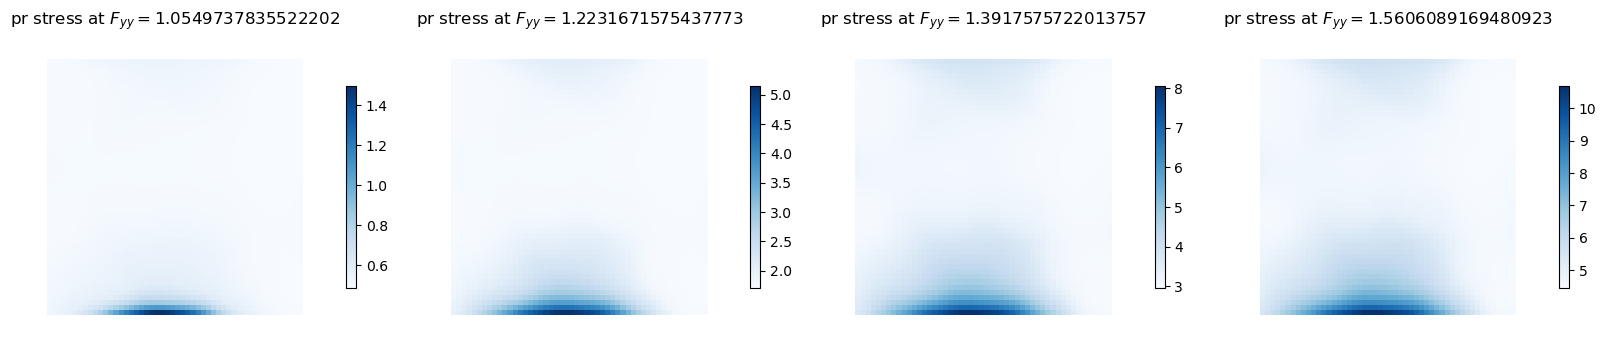

In [5]:
with open('params/AM_stiff2_pre.npy', 'rb') as f:
    coord_2_strain_params, node_params, Lambda_params, mesh, elem_X, P_xx_gt, P_yy_gt, strains, \
                 bd_X, F_hist, t_hist, disps_mean, disps_stdv, Nx, Ny = pickle.load(f)

common_params, sample_params = split_c_s_params(node_params)
phi, unravel = ravel_pytree(sample_params)
NODE_w_unravel = lambda params: NODE_model_aniso(merge_c_s_params(common_params, unravel(params)))


a1 = 1.0
a2 = 1.0
a3 = 0.1*2**(-3)
@jit
def loss(Lambda_params, XYt_colloc):
    Div_x, Div_y = divergence(Lambda_params, XYt_colloc, coord_2_strain_params, NODE_w_unravel)
    loss_Div = (Div_x**2 + Div_y**2)

    def bd_forces_loss(_, t):
        F_rgt, F_top, F_lft, F_bot = bd_forces(Lambda_params, t, bd_X, coord_2_strain_params, NODE_w_unravel)
        P_rgt, P_top, P_lft, P_bot = F_rgt/Ny, F_top/Nx, F_lft/Ny, F_bot/Nx
        Px = P_xx_gt[jnp.array(t, int)]
        Py = P_yy_gt[jnp.array(t, int)]
        return None, ((P_rgt-Px)**2 + (P_top-Py)**2 + (P_lft-Px)**2 + (P_bot-Py)**2)
    loss_F = jnp.mean(scan(bd_forces_loss, init=None, xs=t_hist)[1])
    
    # Add TVR loss
    tvr_loss = 0.0
    Lambda_inp = jnp.array([XYt_colloc[:,0],XYt_colloc[:,1]]).reshape([-1,2])
    for i in range(len(phi)):
        grads = vmap(grad(lambda inp: ff_nn(inp, Lambda_params)[i]))(Lambda_inp) # Take derivative of the ith output wrt the input vector
        tvr_loss += jnp.mean(jnp.sum(grads*grads, axis=1))
     
    return a1*loss_Div + a2*loss_F + a3*tvr_loss

lr = optimizers.exponential_decay(1e-5, 5000, 0.9)
sharding = PositionalSharding(jax.devices()).reshape(n_cores, 1)
opt_init, opt_update, get_params = optimizers.adam(lr) 
opt_state = opt_init(Lambda_params)

Lambda_params, val_loss, metrics = train_colloc(loss, [mesh.points, t_hist], get_params, opt_update, opt_state, 
                                            key, sharding, 'cross', nIter = 10000, print_freq=1000, batch_size=1000)

with open('params/AM_stiff2_TVR-3_post.npy', 'wb') as f:
    pickle.dump([mesh, elem_X, strains, P_xx_gt, P_yy_gt, node_params, Lambda_params, val_loss, metrics, t_hist], f)

# Stiffness across the domain
fig, axes = plt.subplots(1,4,figsize=(20,4))
cell_type = get_meshio_cell_type('QUAD4')
Nx, Ny = 50, 50
Lx, Ly = 1.0, 1.0
meshio_mesh = rectangle_mesh(Nx=Nx, Ny=Ny, domain_x=Lx, domain_y=Ly)
mesh2 = Mesh(meshio_mesh.points, meshio_mesh.cells_dict[cell_type])
elem_X2 = mesh2.points[mesh2.cells].mean(axis=1)
for F_xx, F_yy, F_xy, F_yx, ax in zip(F_xx_mean, F_yy_mean, F_xy_mean, F_yx_mean, axes.T):
    F = np.array([[F_xx, F_xy],
                  [F_yx, F_yy]])
    ugrad = F - np.eye(2)

    params_pr = ff_nn(elem_X2, Lambda_params)

    c_elem_pr = []
    for params_pr_i in params_pr:
        c_elem_pr.append(ThreeDElasticity(NODE_w_unravel).ugrad_2_P(ugrad, params_pr_i, 2)[1,1])
    plotmesh(mesh2.cells, mesh2.points, c_elem_pr, title='pr stress at $F_{yy}=$' + str(F_yy), ax=ax, ec='None'); 

it 1, val loss = 4.211592e+00
it 1001, val loss = 8.039745e-01
it 2001, val loss = 7.150191e-01
it 3001, val loss = 6.099043e-01
it 4001, val loss = 5.982143e-01
it 5001, val loss = 5.607836e-01
it 6001, val loss = 5.217126e-01
it 7001, val loss = 5.893679e-01
it 8001, val loss = 4.989495e-01
it 9001, val loss = 4.480900e-01


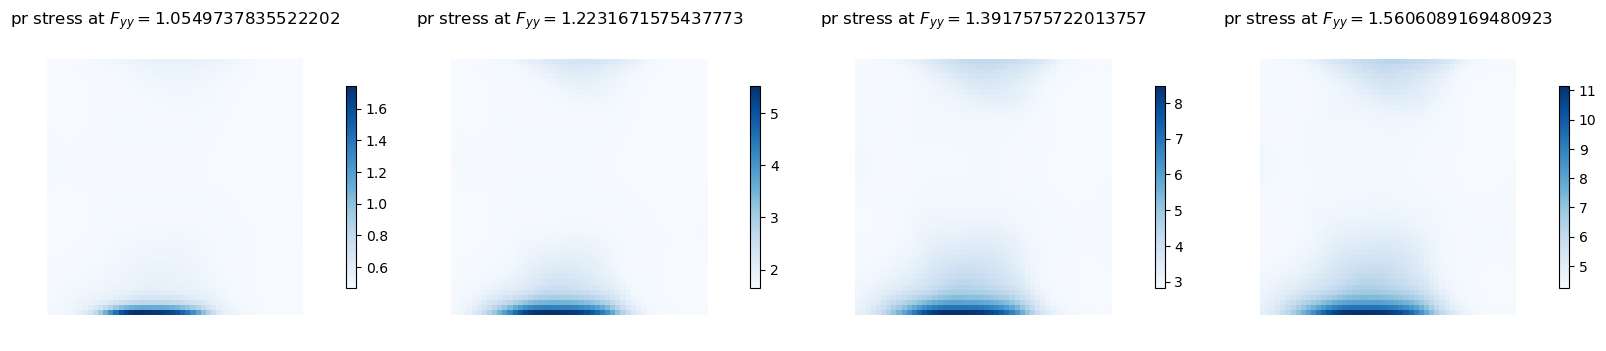

In [6]:
with open('params/AM_stiff2_pre.npy', 'rb') as f:
    coord_2_strain_params, node_params, Lambda_params, mesh, elem_X, P_xx_gt, P_yy_gt, strains, \
                 bd_X, F_hist, t_hist, disps_mean, disps_stdv, Nx, Ny = pickle.load(f)

common_params, sample_params = split_c_s_params(node_params)
phi, unravel = ravel_pytree(sample_params)
NODE_w_unravel = lambda params: NODE_model_aniso(merge_c_s_params(common_params, unravel(params)))


a1 = 1.0
a2 = 1.0
a3 = 0.1*2**(-4)
@jit
def loss(Lambda_params, XYt_colloc):
    Div_x, Div_y = divergence(Lambda_params, XYt_colloc, coord_2_strain_params, NODE_w_unravel)
    loss_Div = (Div_x**2 + Div_y**2)

    def bd_forces_loss(_, t):
        F_rgt, F_top, F_lft, F_bot = bd_forces(Lambda_params, t, bd_X, coord_2_strain_params, NODE_w_unravel)
        P_rgt, P_top, P_lft, P_bot = F_rgt/Ny, F_top/Nx, F_lft/Ny, F_bot/Nx
        Px = P_xx_gt[jnp.array(t, int)]
        Py = P_yy_gt[jnp.array(t, int)]
        return None, ((P_rgt-Px)**2 + (P_top-Py)**2 + (P_lft-Px)**2 + (P_bot-Py)**2)
    loss_F = jnp.mean(scan(bd_forces_loss, init=None, xs=t_hist)[1])
    
    # Add TVR loss
    tvr_loss = 0.0
    Lambda_inp = jnp.array([XYt_colloc[:,0],XYt_colloc[:,1]]).reshape([-1,2])
    for i in range(len(phi)):
        grads = vmap(grad(lambda inp: ff_nn(inp, Lambda_params)[i]))(Lambda_inp) # Take derivative of the ith output wrt the input vector
        tvr_loss += jnp.mean(jnp.sum(grads*grads, axis=1))
     
    return a1*loss_Div + a2*loss_F + a3*tvr_loss

lr = optimizers.exponential_decay(1e-5, 5000, 0.9)
sharding = PositionalSharding(jax.devices()).reshape(n_cores, 1)
opt_init, opt_update, get_params = optimizers.adam(lr) 
opt_state = opt_init(Lambda_params)

Lambda_params, val_loss, metrics = train_colloc(loss, [mesh.points, t_hist], get_params, opt_update, opt_state, 
                                            key, sharding, 'cross', nIter = 10000, print_freq=1000, batch_size=1000)

with open('params/AM_stiff2_TVR-4_post.npy', 'wb') as f:
    pickle.dump([mesh, elem_X, strains, P_xx_gt, P_yy_gt, node_params, Lambda_params, val_loss, metrics, t_hist], f)

# Stiffness across the domain
fig, axes = plt.subplots(1,4,figsize=(20,4))
cell_type = get_meshio_cell_type('QUAD4')
Nx, Ny = 50, 50
Lx, Ly = 1.0, 1.0
meshio_mesh = rectangle_mesh(Nx=Nx, Ny=Ny, domain_x=Lx, domain_y=Ly)
mesh2 = Mesh(meshio_mesh.points, meshio_mesh.cells_dict[cell_type])
elem_X2 = mesh2.points[mesh2.cells].mean(axis=1)
for F_xx, F_yy, F_xy, F_yx, ax in zip(F_xx_mean, F_yy_mean, F_xy_mean, F_yx_mean, axes.T):
    F = np.array([[F_xx, F_xy],
                  [F_yx, F_yy]])
    ugrad = F - np.eye(2)

    params_pr = ff_nn(elem_X2, Lambda_params)

    c_elem_pr = []
    for params_pr_i in params_pr:
        c_elem_pr.append(ThreeDElasticity(NODE_w_unravel).ugrad_2_P(ugrad, params_pr_i, 2)[1,1])
    plotmesh(mesh2.cells, mesh2.points, c_elem_pr, title='pr stress at $F_{yy}=$' + str(F_yy), ax=ax, ec='None'); 

it 1, val loss = 4.211957e+00
it 1001, val loss = 3.133078e+00
it 2001, val loss = 1.935153e+00
it 3001, val loss = 1.602437e+00
it 4001, val loss = 1.276840e+00
it 5001, val loss = 1.007799e+00
it 6001, val loss = 8.621851e-01
it 7001, val loss = 9.535312e-01
it 8001, val loss = 1.014783e+00
it 9001, val loss = 9.226558e-01


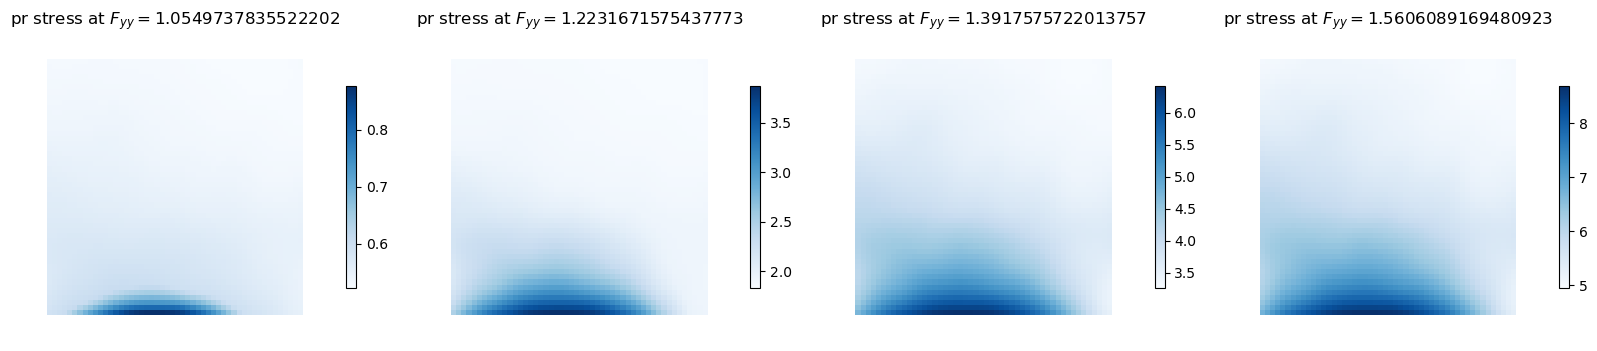

In [7]:
with open('params/AM_stiff2_pre.npy', 'rb') as f:
    coord_2_strain_params, node_params, Lambda_params, mesh, elem_X, P_xx_gt, P_yy_gt, strains, \
                 bd_X, F_hist, t_hist, disps_mean, disps_stdv, Nx, Ny = pickle.load(f)

common_params, sample_params = split_c_s_params(node_params)
phi, unravel = ravel_pytree(sample_params)
NODE_w_unravel = lambda params: NODE_model_aniso(merge_c_s_params(common_params, unravel(params)))


a1 = 1.0
a2 = 1.0
a3 = 0.1*2**(1)
@jit
def loss(Lambda_params, XYt_colloc):
    Div_x, Div_y = divergence(Lambda_params, XYt_colloc, coord_2_strain_params, NODE_w_unravel)
    loss_Div = (Div_x**2 + Div_y**2)

    def bd_forces_loss(_, t):
        F_rgt, F_top, F_lft, F_bot = bd_forces(Lambda_params, t, bd_X, coord_2_strain_params, NODE_w_unravel)
        P_rgt, P_top, P_lft, P_bot = F_rgt/Ny, F_top/Nx, F_lft/Ny, F_bot/Nx
        Px = P_xx_gt[jnp.array(t, int)]
        Py = P_yy_gt[jnp.array(t, int)]
        return None, ((P_rgt-Px)**2 + (P_top-Py)**2 + (P_lft-Px)**2 + (P_bot-Py)**2)
    loss_F = jnp.mean(scan(bd_forces_loss, init=None, xs=t_hist)[1])
    
    # Add TVR loss
    tvr_loss = 0.0
    Lambda_inp = jnp.array([XYt_colloc[:,0],XYt_colloc[:,1]]).reshape([-1,2])
    for i in range(len(phi)):
        grads = vmap(grad(lambda inp: ff_nn(inp, Lambda_params)[i]))(Lambda_inp) # Take derivative of the ith output wrt the input vector
        tvr_loss += jnp.mean(jnp.sum(grads*grads, axis=1))
     
    return a1*loss_Div + a2*loss_F + a3*tvr_loss

lr = optimizers.exponential_decay(1e-5, 5000, 0.9)
sharding = PositionalSharding(jax.devices()).reshape(n_cores, 1)
opt_init, opt_update, get_params = optimizers.adam(lr) 
opt_state = opt_init(Lambda_params)

Lambda_params, val_loss, metrics = train_colloc(loss, [mesh.points, t_hist], get_params, opt_update, opt_state, 
                                            key, sharding, 'cross', nIter = 10000, print_freq=1000, batch_size=1000)

with open('params/AM_stiff2_TVR+1_post.npy', 'wb') as f:
    pickle.dump([mesh, elem_X, strains, P_xx_gt, P_yy_gt, node_params, Lambda_params, val_loss, metrics, t_hist], f)

# Stiffness across the domain
fig, axes = plt.subplots(1,4,figsize=(20,4))
cell_type = get_meshio_cell_type('QUAD4')
Nx, Ny = 50, 50
Lx, Ly = 1.0, 1.0
meshio_mesh = rectangle_mesh(Nx=Nx, Ny=Ny, domain_x=Lx, domain_y=Ly)
mesh2 = Mesh(meshio_mesh.points, meshio_mesh.cells_dict[cell_type])
elem_X2 = mesh2.points[mesh2.cells].mean(axis=1)
for F_xx, F_yy, F_xy, F_yx, ax in zip(F_xx_mean, F_yy_mean, F_xy_mean, F_yx_mean, axes.T):
    F = np.array([[F_xx, F_xy],
                  [F_yx, F_yy]])
    ugrad = F - np.eye(2)

    params_pr = ff_nn(elem_X2, Lambda_params)

    c_elem_pr = []
    for params_pr_i in params_pr:
        c_elem_pr.append(ThreeDElasticity(NODE_w_unravel).ugrad_2_P(ugrad, params_pr_i, 2)[1,1])
    plotmesh(mesh2.cells, mesh2.points, c_elem_pr, title='pr stress at $F_{yy}=$' + str(F_yy), ax=ax, ec='None'); 

it 1, val loss = 4.212331e+00
it 1001, val loss = 3.634442e+00
it 2001, val loss = 2.023661e+00
it 3001, val loss = 1.490876e+00
it 4001, val loss = 1.515126e+00
it 5001, val loss = 1.044845e+00
it 6001, val loss = 9.078904e-01
it 7001, val loss = 9.425097e-01
it 8001, val loss = 1.155319e+00
it 9001, val loss = 1.015673e+00


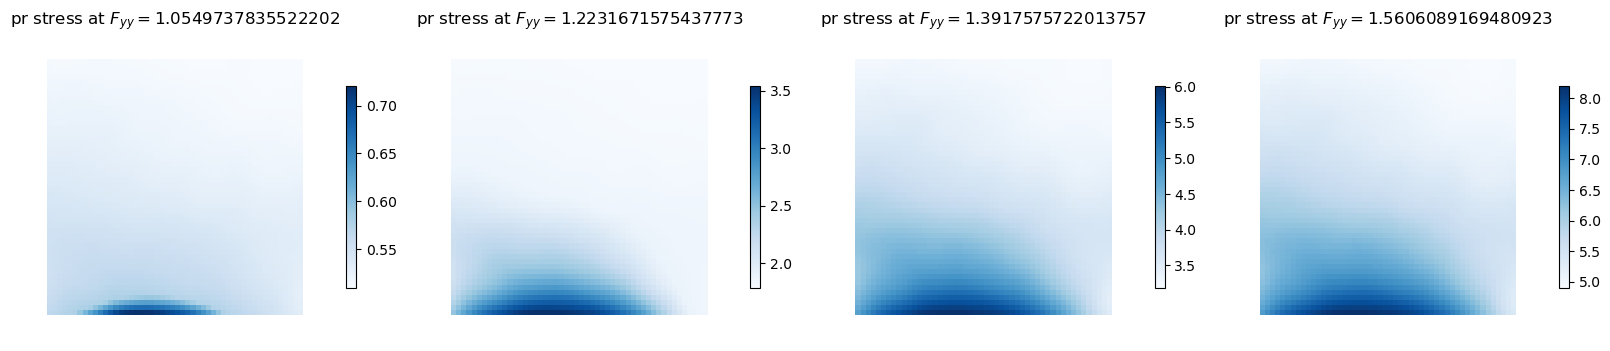

In [8]:
with open('params/AM_stiff2_pre.npy', 'rb') as f:
    coord_2_strain_params, node_params, Lambda_params, mesh, elem_X, P_xx_gt, P_yy_gt, strains, \
                 bd_X, F_hist, t_hist, disps_mean, disps_stdv, Nx, Ny = pickle.load(f)

common_params, sample_params = split_c_s_params(node_params)
phi, unravel = ravel_pytree(sample_params)
NODE_w_unravel = lambda params: NODE_model_aniso(merge_c_s_params(common_params, unravel(params)))


a1 = 1.0
a2 = 1.0
a3 = 0.1*2**(+2)
@jit
def loss(Lambda_params, XYt_colloc):
    Div_x, Div_y = divergence(Lambda_params, XYt_colloc, coord_2_strain_params, NODE_w_unravel)
    loss_Div = (Div_x**2 + Div_y**2)

    def bd_forces_loss(_, t):
        F_rgt, F_top, F_lft, F_bot = bd_forces(Lambda_params, t, bd_X, coord_2_strain_params, NODE_w_unravel)
        P_rgt, P_top, P_lft, P_bot = F_rgt/Ny, F_top/Nx, F_lft/Ny, F_bot/Nx
        Px = P_xx_gt[jnp.array(t, int)]
        Py = P_yy_gt[jnp.array(t, int)]
        return None, ((P_rgt-Px)**2 + (P_top-Py)**2 + (P_lft-Px)**2 + (P_bot-Py)**2)
    loss_F = jnp.mean(scan(bd_forces_loss, init=None, xs=t_hist)[1])
    
    # Add TVR loss
    tvr_loss = 0.0
    Lambda_inp = jnp.array([XYt_colloc[:,0],XYt_colloc[:,1]]).reshape([-1,2])
    for i in range(len(phi)):
        grads = vmap(grad(lambda inp: ff_nn(inp, Lambda_params)[i]))(Lambda_inp) # Take derivative of the ith output wrt the input vector
        tvr_loss += jnp.mean(jnp.sum(grads*grads, axis=1))
     
    return a1*loss_Div + a2*loss_F + a3*tvr_loss

lr = optimizers.exponential_decay(1e-5, 5000, 0.9)
sharding = PositionalSharding(jax.devices()).reshape(n_cores, 1)
opt_init, opt_update, get_params = optimizers.adam(lr) 
opt_state = opt_init(Lambda_params)

Lambda_params, val_loss, metrics = train_colloc(loss, [mesh.points, t_hist], get_params, opt_update, opt_state, 
                                            key, sharding, 'cross', nIter = 10000, print_freq=1000, batch_size=1000)

with open('params/AM_stiff2_TVR+2_post.npy', 'wb') as f:
    pickle.dump([mesh, elem_X, strains, P_xx_gt, P_yy_gt, node_params, Lambda_params, val_loss, metrics, t_hist], f)

# Stiffness across the domain
fig, axes = plt.subplots(1,4,figsize=(20,4))
cell_type = get_meshio_cell_type('QUAD4')
Nx, Ny = 50, 50
Lx, Ly = 1.0, 1.0
meshio_mesh = rectangle_mesh(Nx=Nx, Ny=Ny, domain_x=Lx, domain_y=Ly)
mesh2 = Mesh(meshio_mesh.points, meshio_mesh.cells_dict[cell_type])
elem_X2 = mesh2.points[mesh2.cells].mean(axis=1)
for F_xx, F_yy, F_xy, F_yx, ax in zip(F_xx_mean, F_yy_mean, F_xy_mean, F_yx_mean, axes.T):
    F = np.array([[F_xx, F_xy],
                  [F_yx, F_yy]])
    ugrad = F - np.eye(2)

    params_pr = ff_nn(elem_X2, Lambda_params)

    c_elem_pr = []
    for params_pr_i in params_pr:
        c_elem_pr.append(ThreeDElasticity(NODE_w_unravel).ugrad_2_P(ugrad, params_pr_i, 2)[1,1])
    plotmesh(mesh2.cells, mesh2.points, c_elem_pr, title='pr stress at $F_{yy}=$' + str(F_yy), ax=ax, ec='None'); 

it 1, val loss = 4.213078e+00
it 1001, val loss = 3.290994e+00
it 2001, val loss = 3.262892e+00
it 3001, val loss = 3.045200e+00
it 4001, val loss = 2.712096e+00
it 5001, val loss = 2.422720e+00
it 6001, val loss = 2.140883e+00
it 7001, val loss = 1.774039e+00
it 8001, val loss = 1.660098e+00
it 9001, val loss = 1.543964e+00


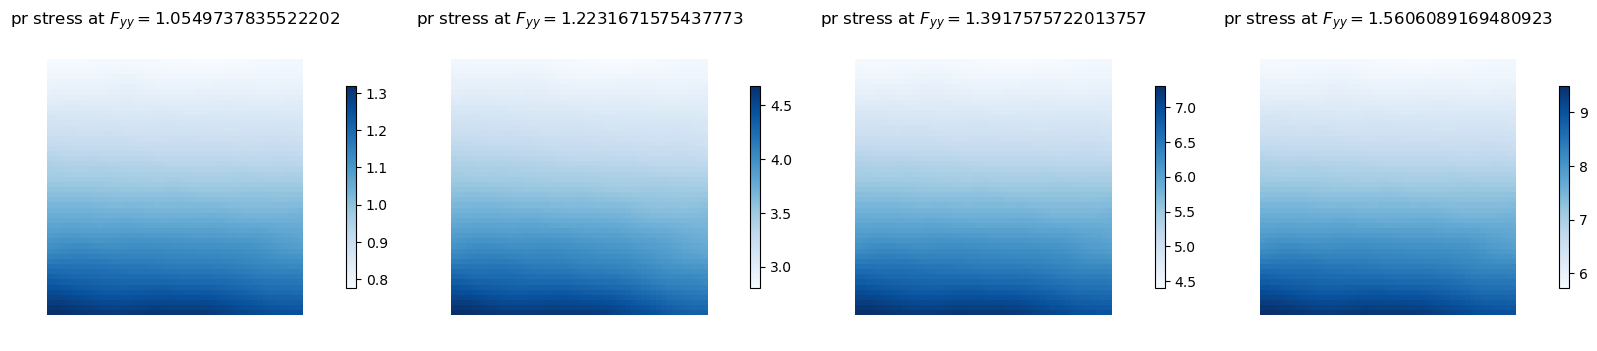

In [9]:
with open('params/AM_stiff2_pre.npy', 'rb') as f:
    coord_2_strain_params, node_params, Lambda_params, mesh, elem_X, P_xx_gt, P_yy_gt, strains, \
                 bd_X, F_hist, t_hist, disps_mean, disps_stdv, Nx, Ny = pickle.load(f)

common_params, sample_params = split_c_s_params(node_params)
phi, unravel = ravel_pytree(sample_params)
NODE_w_unravel = lambda params: NODE_model_aniso(merge_c_s_params(common_params, unravel(params)))


a1 = 1.0
a2 = 1.0
a3 = 0.1*2**(+3)
@jit
def loss(Lambda_params, XYt_colloc):
    Div_x, Div_y = divergence(Lambda_params, XYt_colloc, coord_2_strain_params, NODE_w_unravel)
    loss_Div = (Div_x**2 + Div_y**2)

    def bd_forces_loss(_, t):
        F_rgt, F_top, F_lft, F_bot = bd_forces(Lambda_params, t, bd_X, coord_2_strain_params, NODE_w_unravel)
        P_rgt, P_top, P_lft, P_bot = F_rgt/Ny, F_top/Nx, F_lft/Ny, F_bot/Nx
        Px = P_xx_gt[jnp.array(t, int)]
        Py = P_yy_gt[jnp.array(t, int)]
        return None, ((P_rgt-Px)**2 + (P_top-Py)**2 + (P_lft-Px)**2 + (P_bot-Py)**2)
    loss_F = jnp.mean(scan(bd_forces_loss, init=None, xs=t_hist)[1])
    
    # Add TVR loss
    tvr_loss = 0.0
    Lambda_inp = jnp.array([XYt_colloc[:,0],XYt_colloc[:,1]]).reshape([-1,2])
    for i in range(len(phi)):
        grads = vmap(grad(lambda inp: ff_nn(inp, Lambda_params)[i]))(Lambda_inp) # Take derivative of the ith output wrt the input vector
        tvr_loss += jnp.mean(jnp.sum(grads*grads, axis=1))
     
    return a1*loss_Div + a2*loss_F + a3*tvr_loss

lr = optimizers.exponential_decay(1e-5, 5000, 0.9)
sharding = PositionalSharding(jax.devices()).reshape(n_cores, 1)
opt_init, opt_update, get_params = optimizers.adam(lr) 
opt_state = opt_init(Lambda_params)

Lambda_params, val_loss, metrics = train_colloc(loss, [mesh.points, t_hist], get_params, opt_update, opt_state, 
                                            key, sharding, 'cross', nIter = 10000, print_freq=1000, batch_size=1000)

with open('params/AM_stiff2_TVR+3_post.npy', 'wb') as f:
    pickle.dump([mesh, elem_X, strains, P_xx_gt, P_yy_gt, node_params, Lambda_params, val_loss, metrics, t_hist], f)

# Stiffness across the domain
fig, axes = plt.subplots(1,4,figsize=(20,4))
cell_type = get_meshio_cell_type('QUAD4')
Nx, Ny = 50, 50
Lx, Ly = 1.0, 1.0
meshio_mesh = rectangle_mesh(Nx=Nx, Ny=Ny, domain_x=Lx, domain_y=Ly)
mesh2 = Mesh(meshio_mesh.points, meshio_mesh.cells_dict[cell_type])
elem_X2 = mesh2.points[mesh2.cells].mean(axis=1)
for F_xx, F_yy, F_xy, F_yx, ax in zip(F_xx_mean, F_yy_mean, F_xy_mean, F_yx_mean, axes.T):
    F = np.array([[F_xx, F_xy],
                  [F_yx, F_yy]])
    ugrad = F - np.eye(2)

    params_pr = ff_nn(elem_X2, Lambda_params)

    c_elem_pr = []
    for params_pr_i in params_pr:
        c_elem_pr.append(ThreeDElasticity(NODE_w_unravel).ugrad_2_P(ugrad, params_pr_i, 2)[1,1])
    plotmesh(mesh2.cells, mesh2.points, c_elem_pr, title='pr stress at $F_{yy}=$' + str(F_yy), ax=ax, ec='None'); 

it 1, val loss = 4.214572e+00
it 1001, val loss = 3.298306e+00
it 2001, val loss = 3.305477e+00
it 3001, val loss = 3.282728e+00
it 4001, val loss = 3.092176e+00
it 5001, val loss = 2.903339e+00
it 6001, val loss = 2.755137e+00
it 7001, val loss = 2.320250e+00
it 8001, val loss = 2.188048e+00
it 9001, val loss = 1.993058e+00


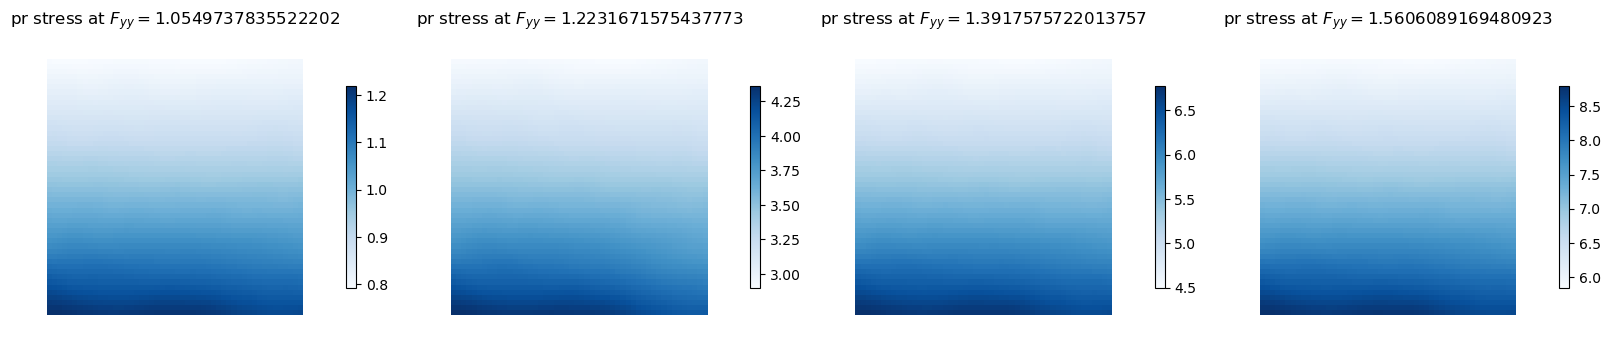

In [10]:
with open('params/AM_stiff2_pre.npy', 'rb') as f:
    coord_2_strain_params, node_params, Lambda_params, mesh, elem_X, P_xx_gt, P_yy_gt, strains, \
                 bd_X, F_hist, t_hist, disps_mean, disps_stdv, Nx, Ny = pickle.load(f)

common_params, sample_params = split_c_s_params(node_params)
phi, unravel = ravel_pytree(sample_params)
NODE_w_unravel = lambda params: NODE_model_aniso(merge_c_s_params(common_params, unravel(params)))


a1 = 1.0
a2 = 1.0
a3 = 0.1*2**(+4)
@jit
def loss(Lambda_params, XYt_colloc):
    Div_x, Div_y = divergence(Lambda_params, XYt_colloc, coord_2_strain_params, NODE_w_unravel)
    loss_Div = (Div_x**2 + Div_y**2)

    def bd_forces_loss(_, t):
        F_rgt, F_top, F_lft, F_bot = bd_forces(Lambda_params, t, bd_X, coord_2_strain_params, NODE_w_unravel)
        P_rgt, P_top, P_lft, P_bot = F_rgt/Ny, F_top/Nx, F_lft/Ny, F_bot/Nx
        Px = P_xx_gt[jnp.array(t, int)]
        Py = P_yy_gt[jnp.array(t, int)]
        return None, ((P_rgt-Px)**2 + (P_top-Py)**2 + (P_lft-Px)**2 + (P_bot-Py)**2)
    loss_F = jnp.mean(scan(bd_forces_loss, init=None, xs=t_hist)[1])
    
    # Add TVR loss
    tvr_loss = 0.0
    Lambda_inp = jnp.array([XYt_colloc[:,0],XYt_colloc[:,1]]).reshape([-1,2])
    for i in range(len(phi)):
        grads = vmap(grad(lambda inp: ff_nn(inp, Lambda_params)[i]))(Lambda_inp) # Take derivative of the ith output wrt the input vector
        tvr_loss += jnp.mean(jnp.sum(grads*grads, axis=1))
     
    return a1*loss_Div + a2*loss_F + a3*tvr_loss

lr = optimizers.exponential_decay(1e-5, 5000, 0.9)
sharding = PositionalSharding(jax.devices()).reshape(n_cores, 1)
opt_init, opt_update, get_params = optimizers.adam(lr) 
opt_state = opt_init(Lambda_params)

Lambda_params, val_loss, metrics = train_colloc(loss, [mesh.points, t_hist], get_params, opt_update, opt_state, 
                                            key, sharding, 'cross', nIter = 10000, print_freq=1000, batch_size=1000)

with open('params/AM_stiff2_TVR+4_post.npy', 'wb') as f:
    pickle.dump([mesh, elem_X, strains, P_xx_gt, P_yy_gt, node_params, Lambda_params, val_loss, metrics, t_hist], f)

# Stiffness across the domain
fig, axes = plt.subplots(1,4,figsize=(20,4))
cell_type = get_meshio_cell_type('QUAD4')
Nx, Ny = 50, 50
Lx, Ly = 1.0, 1.0
meshio_mesh = rectangle_mesh(Nx=Nx, Ny=Ny, domain_x=Lx, domain_y=Ly)
mesh2 = Mesh(meshio_mesh.points, meshio_mesh.cells_dict[cell_type])
elem_X2 = mesh2.points[mesh2.cells].mean(axis=1)
for F_xx, F_yy, F_xy, F_yx, ax in zip(F_xx_mean, F_yy_mean, F_xy_mean, F_yx_mean, axes.T):
    F = np.array([[F_xx, F_xy],
                  [F_yx, F_yy]])
    ugrad = F - np.eye(2)

    params_pr = ff_nn(elem_X2, Lambda_params)

    c_elem_pr = []
    for params_pr_i in params_pr:
        c_elem_pr.append(ThreeDElasticity(NODE_w_unravel).ugrad_2_P(ugrad, params_pr_i, 2)[1,1])
    plotmesh(mesh2.cells, mesh2.points, c_elem_pr, title='pr stress at $F_{yy}=$' + str(F_yy), ax=ax, ec='None'); 

In [4]:
P_vmap = vmap(ThreeDElasticity(NODE_w_unravel).ugrad_2_P, in_axes=(0, 0, None))
class HyperElasticity(FEM):
    def get_tensor_map(self):
        return lambda u_grad, params: ThreeDElasticity(NODE_w_unravel).ugrad_2_P(u_grad, params, self.dim)
    
    def set_params(self, params_vec):
        self.internal_vars['laplace'] = [params_vec]

In [5]:
params_vec = []
for x, y in elem_X:
    Lambda_inp = np.array([x,y]).reshape([-1,2])
    phi = ff_nn(Lambda_inp, Lambda_params).flatten()
    params_vec.append(phi)
params_vec = jnp.array(params_vec).reshape([len(params_vec),1,-1])
params_vec = jnp.repeat(params_vec, axis=1, repeats=4)

In [6]:
ele_type = 'QUAD4'
cell_type = get_meshio_cell_type(ele_type)

Nx, Ny = 19, 19
Lx, Ly = 1.0, 1.0
meshio_mesh = rectangle_mesh(Nx=Nx, Ny=Ny, domain_x=Lx, domain_y=Ly)
mesh = Mesh(meshio_mesh.points, meshio_mesh.cells_dict[cell_type])


# Functions to identify the boundary nodes
def bottom(point):
    return jnp.isclose(point[1], 0., atol=1e-5)
def left(point):
    return jnp.isclose(point[0], 0., atol=1e-5)
def top(point):
    return jnp.isclose(point[1], Ly, atol=1e-5)
def right(point):
    return jnp.isclose(point[0], Lx, atol=1e-5)
def bottom_left(point):
    return jnp.logical_and(jnp.logical_and(bottom(point), left(point)), jnp.isclose(point[2], 0., atol=1e-5))


# Functions to assign dirichlet BCs
def zero_dirichlet(point):
    return 0.
def lmbx_max_dirichlet(point, lmbx_max):
    return Lx*lmbx_max - 1.0
def lmby_max_dirichlet(point, lmby_max):
    return Ly*lmby_max - 1.0


lmb_hist = [1.05, 1.10, 1.15, 1.20]
n_elem = Nx*Ny
C10 = jnp.zeros(n_elem)
k1  = jnp.zeros(n_elem)
k2  = jnp.zeros(n_elem)
F_hist = []
node_x_hist = []
P_hist = []
for lmb_max in lmb_hist:
    dirichlet_bc_info = [
        [bottom,            left,           top,                                        right,                                  ],
        [1,                 0,              1,                                          0,                                      ],
        [zero_dirichlet,    zero_dirichlet, lambda p: lmby_max_dirichlet(p, lmb_max),   lambda p: lmbx_max_dirichlet(p, lmb_max)]
    ]
    problem = HyperElasticity(mesh,
                            vec=2,
                            dim=2,
                            ele_type=ele_type,
                            dirichlet_bc_info=dirichlet_bc_info)
    elem_X = problem.get_physical_quad_points().mean(1)

    problem.set_params(params_vec)


    node_x = solver(problem, use_petsc=True)
    u_grad = np.mean(problem.sol_to_grad(node_x), axis=1)
    F = u_grad + np.eye(2)
    P = P_vmap(u_grad, params_vec[:,0,:], 2)
    
    F_hist.append(F)
    node_x_hist.append(node_x)
    P_hist.append(P)
node_x_hist = np.array(node_x_hist)
F_hist = np.array(F_hist)
P_hist = np.array(P_hist)

[01-29 12:02:18][DEBUG] jax_fem: Computing shape function values, gradients, etc.
[01-29 12:02:18][DEBUG] jax_fem: ele_type = QUAD4, quad_points.shape = (num_quads, dim) = (4, 2)
[01-29 12:02:18][DEBUG] jax_fem: face_quad_points.shape = (num_faces, num_face_quads, dim) = (4, 2, 2)
[01-29 12:02:19][DEBUG] jax_fem: Done pre-computations, took 0.3462047576904297 [s]
[01-29 12:02:19][INFO] jax_fem: Solving a problem with 361 cells, 400x2 = 800 dofs.
[01-29 12:02:19][DEBUG] jax_fem: Calling the row elimination solver for imposing Dirichlet B.C.
[01-29 12:02:19][DEBUG] jax_fem: Start timing
[01-29 12:02:19][DEBUG] jax_fem: Computing cell Jacobian and cell residual...
[01-29 12:02:22][DEBUG] jax_fem: Function split_and_compute_cell took 2.7130 seconds
[01-29 12:02:22][DEBUG] jax_fem: Creating sparse matrix with scipy...
[01-29 12:02:22][DEBUG] jax_fem: Linear guess solve...
[01-29 12:02:22][DEBUG] jax_fem: PETSc - Solving with ksp_type = bcgsl, pc = ilu
[01-29 12:02:22][DEBUG] jax_fem: PETSc 

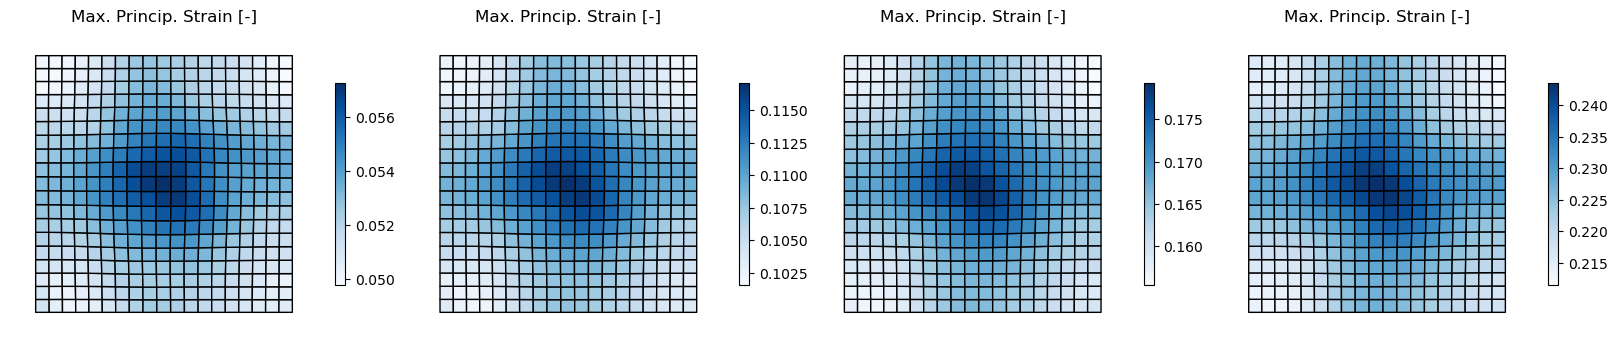

In [8]:
fig, axes = plt.subplots(1,4,figsize=(20,4))
strains = []
t_hist = np.arange(len(lmb_hist))
for t, node_x, F, ax in zip(t_hist, node_x_hist, F_hist, axes):
    E = E_fun(F)
    evals, efuns = jnp.linalg.eigh(E)
    E_11, E_22 = evals.T

    mps = np.maximum(E_11, E_22)
    plotmesh(mesh.cells, mesh.points, mps, title='Max. Princip. Strain [-]', ax=ax); 